# Simulation Results Analysis

## Binary-Ta-NLP-Sector Simulation Results

In [1]:
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    _HAS_SEABORN = True
except Exception:
    _HAS_SEABORN = False

plt.style.use('seaborn-v0_8-whitegrid')


In [2]:
RESULTS_DIR = Path('../results/simulation/binary-ta-nlp-sector')
csv_paths = sorted(RESULTS_DIR.glob('*.csv'))
if not csv_paths:
    raise FileNotFoundError(f'No CSVs found in {RESULTS_DIR.resolve()}')

dfs = {}
for path in csv_paths:
    df = pd.read_csv(path)
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date')

    # Use filename stem as the primary label to avoid collisions
    mode = path.stem
    df['mode'] = mode
    dfs[mode] = df

list(dfs.keys())


['HYBRID_KELLY_MPT_H1_EE_OFF',
 'HYBRID_KELLY_MPT_H1_EE_ON',
 'HYBRID_KELLY_MPT_H5_EE_OFF',
 'HYBRID_KELLY_MPT_H5_EE_ON',
 'KELLY_ONLY_H1_EE_OFF',
 'KELLY_ONLY_H1_EE_ON',
 'KELLY_ONLY_H5_EE_OFF',
 'KELLY_ONLY_H5_EE_ON',
 'MPT_ONLY_H1_EE_OFF',
 'MPT_ONLY_H1_EE_ON',
 'MPT_ONLY_H5_EE_OFF',
 'MPT_ONLY_H5_EE_ON']

In [3]:
import re


def _parse_maybe(value):
    if isinstance(value, (list, dict)):
        return value
    if isinstance(value, float) and np.isnan(value):
        return None
    if isinstance(value, str):
        text = value.strip()
        text = re.sub(r"Timestamp\(\'([^']+)\'\)", r"'\1'", text)
        if text == '' or text.lower() == 'nan':
            return None
        if text[0] in '[{(' and text[-1] in ']})':
            try:
                return ast.literal_eval(text)
            except Exception:
                return None
    return value

def _ensure_returns(df):
    if 'daily_return' not in df.columns and {'equity_start', 'equity_end'}.issubset(df.columns):
        prev_end = df['equity_end'].shift(1).fillna(df['equity_start'])
        df['daily_return'] = (df['equity_start'] / prev_end) - 1.0
    return df

def _metrics_from_df(df, rf=0.0):
    df = df.copy()
    df = _ensure_returns(df)
    rets = df['daily_return'].astype(float).fillna(0.0).values
    if len(rets) == 0:
        return {}

    eq = df['equity_end'] if 'equity_end' in df.columns else None
    start_equity = df['equity_start'].iloc[0] if 'equity_start' in df.columns else np.nan
    end_equity = df['equity_end'].iloc[-1] if 'equity_end' in df.columns else np.nan

    total_return = (end_equity / start_equity - 1.0) if start_equity not in (0, np.nan) else np.nan
    n_days = len(rets)
    ann_factor = 252
    cagr = (1 + total_return) ** (ann_factor / n_days) - 1 if n_days > 0 and np.isfinite(total_return) else np.nan

    vol = np.std(rets, ddof=1) * np.sqrt(ann_factor) if n_days > 1 else np.nan
    mean_ret = np.mean(rets)
    sharpe = (mean_ret - rf / ann_factor) / (np.std(rets, ddof=1) + 1e-12) * np.sqrt(ann_factor) if n_days > 1 else np.nan

    downside = rets[rets < 0]
    sortino = (mean_ret - rf / ann_factor) / (np.std(downside, ddof=1) + 1e-12) * np.sqrt(ann_factor) if len(downside) > 1 else np.nan

    if eq is not None:
        roll_max = eq.cummax()
        drawdown = (eq / roll_max) - 1.0
        max_dd = drawdown.min() if len(drawdown) else np.nan
    else:
        max_dd = np.nan

    win_rate = float(np.mean(rets > 0)) if n_days else np.nan
    avg_win = np.mean(rets[rets > 0]) if np.any(rets > 0) else np.nan
    avg_loss = np.mean(rets[rets < 0]) if np.any(rets < 0) else np.nan
    profit_factor = -np.sum(rets[rets > 0]) / (np.sum(rets[rets < 0]) - 1e-12) if np.any(rets < 0) else np.nan

    return {
        'days': n_days,
        'start_equity': start_equity,
        'end_equity': end_equity,
        'total_return': total_return,
        'CAGR': cagr,
        'volatility': vol,
        'sharpe': sharpe,
        'sortino': sortino,
        'max_drawdown': max_dd,
        'win_rate': win_rate,
        'avg_win': avg_win,
        'avg_loss': avg_loss,
        'profit_factor': profit_factor,
    }


In [4]:
summary_rows = []
for mode, df in dfs.items():
    metrics = _metrics_from_df(df)
    metrics['mode'] = mode
    summary_rows.append(metrics)

summary_df = pd.DataFrame(summary_rows).set_index('mode').sort_values('total_return', ascending=False)
summary_df


,days,start_equity,end_equity,total_return,CAGR,volatility,sharpe,sortino,max_drawdown,win_rate,avg_win,avg_loss,profit_factor
mode,,,,,,,,,,,,,
HYBRID_KELLY_MPT_H5_EE_ON,100,100000.0,106569.082833,0.065691,0.173899,0.036450,4.418052,6.344122,-0.011350,0.65,0.001857,-0.001670,2.125556
KELLY_ONLY_H5_EE_ON,100,100000.0,105946.087665,0.059461,0.156682,0.033388,4.377301,5.925223,-0.011399,0.65,0.001720,-0.001582,2.078124
MPT_ONLY_H5_EE_ON,100,100000.0,104812.978456,0.048130,0.125760,0.035169,3.386514,4.690157,-0.011174,0.62,0.001775,-0.001697,1.752732
HYBRID_KELLY_MPT_H5_EE_OFF,100,100000.0,103939.073103,0.039391,0.102257,0.044432,2.213613,2.623021,-0.035307,0.33,0.002955,-0.002437,1.667428
MPT_ONLY_H5_EE_OFF,100,100000.0,103031.141028,0.030311,0.078154,0.043741,1.742241,1.917623,-0.036713,0.33,0.002855,-0.002665,1.472764
KELLY_ONLY_H5_EE_OFF,100,100000.0,101981.742020,0.019817,0.050695,0.036923,1.357714,1.496473,-0.034001,0.32,0.002383,-0.002254,1.352961
KELLY_ONLY_H1_EE_OFF,100,100000.0,100967.536203,0.009675,0.024561,0.023709,1.035230,1.397734,-0.011143,0.51,0.001189,-0.001060,1.191416
KELLY_ONLY_H1_EE_ON,100,100000.0,100967.536203,0.009675,0.024561,0.023709,1.035230,1.397734,-0.011143,0.51,0.001189,-0.001060,1.191416
MPT_ONLY_H1_EE_OFF,100,100000.0,100012.554033,0.000126,0.000316,0.031278,0.025604,0.035582,-0.019150,0.53,0.001410,-0.001618,1.004271


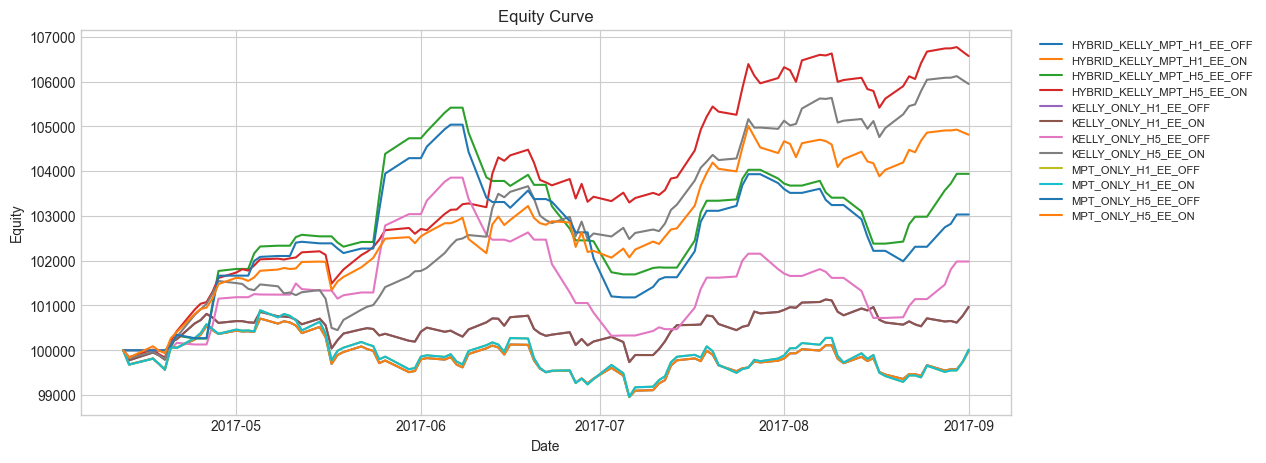

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
for mode, df in dfs.items():
    if 'equity_end' in df.columns:
        ax.plot(df['date'], df['equity_end'], label=mode)
ax.set_title('Equity Curve')
ax.set_xlabel('Date')
ax.set_ylabel('Equity')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()


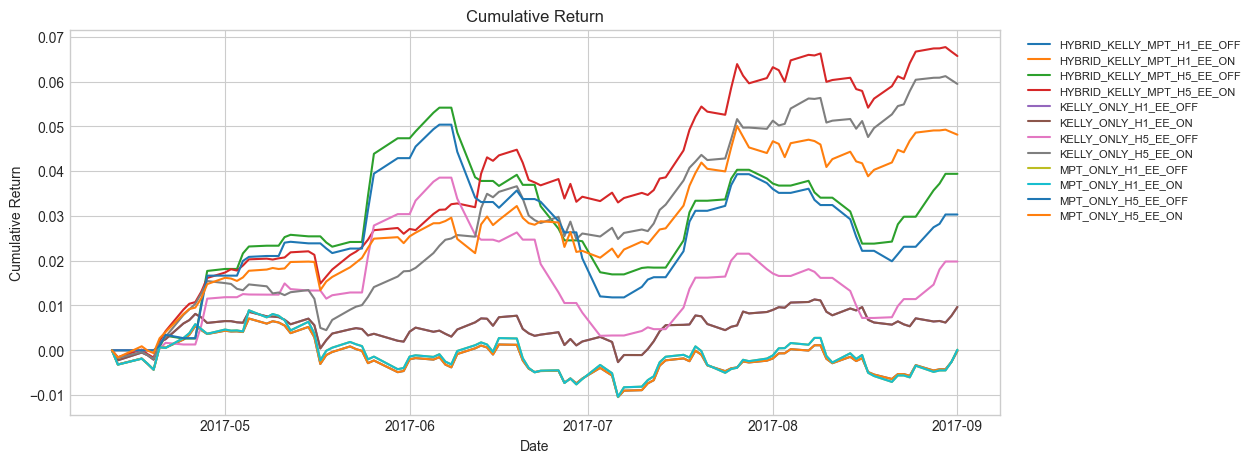

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
for mode, df in dfs.items():
    if 'equity_end' in df.columns and 'equity_start' in df.columns:
        base = df['equity_start'].iloc[0]
        ax.plot(df['date'], df['equity_end'] / base - 1.0, label=mode)
ax.set_title('Cumulative Return')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()


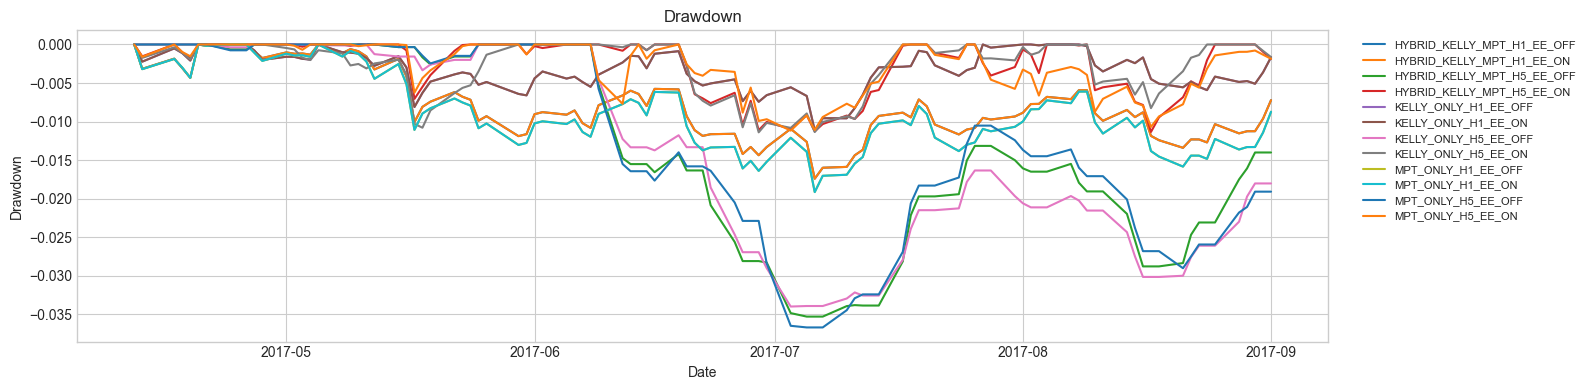

In [7]:
fig, ax = plt.subplots(figsize=(16, 4))
for mode, df in dfs.items():
    if 'equity_end' in df.columns:
        roll_max = df['equity_end'].cummax()
        drawdown = df['equity_end'] / roll_max - 1.0
        ax.plot(df['date'], drawdown, label=mode)
ax.set_title('Drawdown')
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


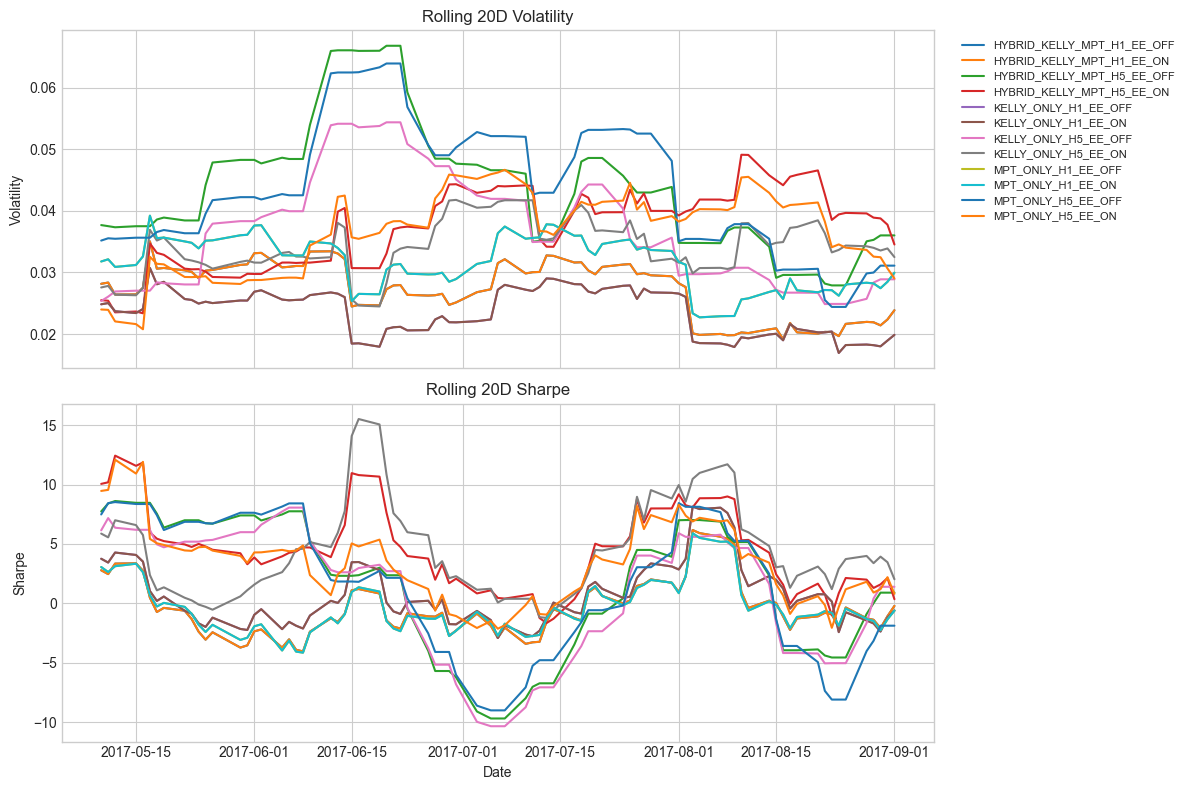

In [8]:
window = 20
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for mode, df in dfs.items():
    df = _ensure_returns(df)
    rets = df['daily_return'].astype(float).fillna(0.0)
    roll_vol = rets.rolling(window).std() * np.sqrt(252)
    roll_sharpe = rets.rolling(window).mean() / (rets.rolling(window).std() + 1e-12) * np.sqrt(252)
    axes[0].plot(df['date'], roll_vol, label=mode)
    axes[1].plot(df['date'], roll_sharpe, label=mode)

axes[0].set_title(f'Rolling {window}D Volatility')
axes[0].set_ylabel('Volatility')
axes[1].set_title(f'Rolling {window}D Sharpe')
axes[1].set_ylabel('Sharpe')
axes[1].set_xlabel('Date')
axes[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


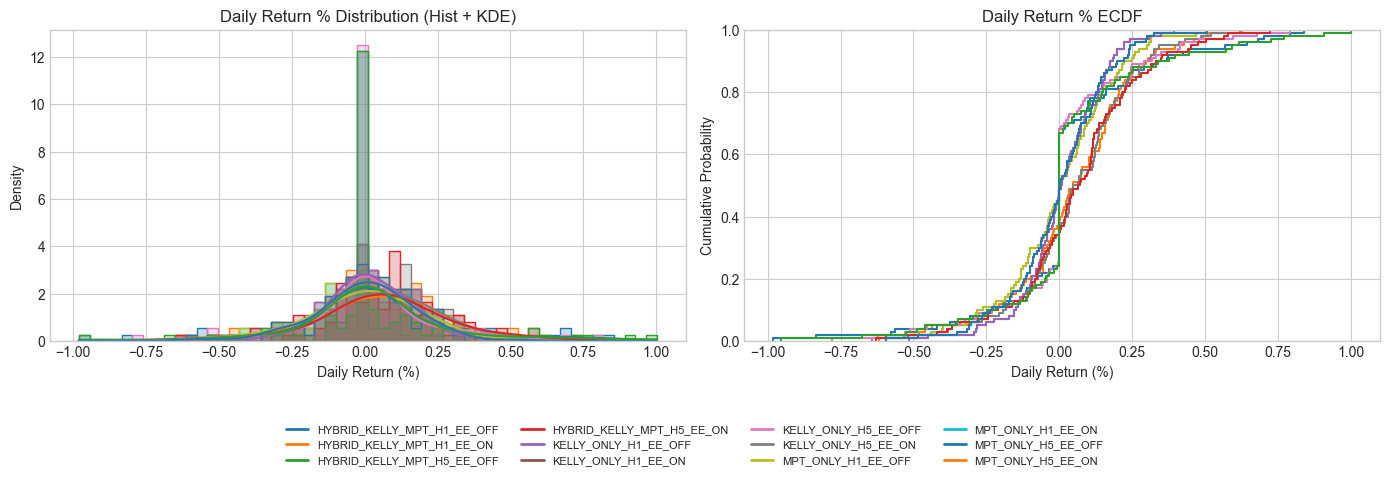

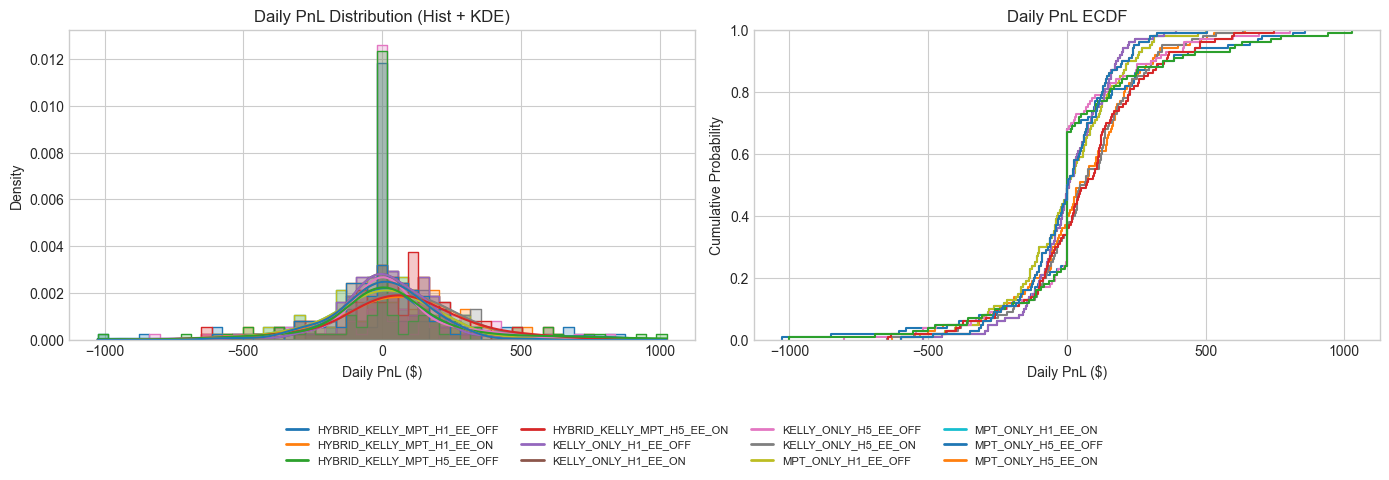

,max_abs_diff,mean_abs_diff,csv_nonnull,calc_nonnull
mode,,,,
HYBRID_KELLY_MPT_H1_EE_OFF,4.920109e-16,1.346370e-16,100,100
HYBRID_KELLY_MPT_H1_EE_ON,4.920109e-16,1.346370e-16,100,100
HYBRID_KELLY_MPT_H5_EE_OFF,3.629909e-16,6.015885e-17,100,100
HYBRID_KELLY_MPT_H5_EE_ON,5.074066e-16,1.253980e-16,100,100
KELLY_ONLY_H1_EE_OFF,5.332106e-16,1.799685e-16,100,100
KELLY_ONLY_H1_EE_ON,5.332106e-16,1.799685e-16,100,100
KELLY_ONLY_H5_EE_OFF,4.444145e-16,7.228620e-17,100,100
KELLY_ONLY_H5_EE_ON,5.219349e-16,1.163129e-16,100,100
MPT_ONLY_H1_EE_OFF,5.162971e-16,1.403874e-16,100,100


In [9]:
def _calc_daily_return(df):
    df = df.copy()
    if 'equity_end' in df.columns:
        prev_end = df['equity_end'].shift(1)
        if 'equity_start' in df.columns:
            prev_end = prev_end.fillna(df['equity_start'])
        else:
            prev_end = prev_end.fillna(df['equity_end'])
        return (df['equity_end'] / prev_end) - 1.0
    if 'daily_pnl_realized' in df.columns and 'equity_start' in df.columns:
        prev_end = df['equity_start'].shift(1).fillna(df['equity_start'])
        return df['daily_pnl_realized'] / prev_end
    if 'daily_return' in df.columns:
        return df['daily_return'].astype(float)
    return pd.Series(np.nan, index=df.index)

all_returns = []
pnl_rows = []
diag_rows = []
for mode, df in dfs.items():
    df = df.copy()
    csv_returns = df['daily_return'].astype(float) if 'daily_return' in df.columns else pd.Series(np.nan, index=df.index)
    calc_returns = _calc_daily_return(df).astype(float)

    diff = (csv_returns - calc_returns).abs()
    diag_rows.append({
        'mode': mode,
        'max_abs_diff': diff.max(),
        'mean_abs_diff': diff.mean(),
        'csv_nonnull': csv_returns.notna().sum(),
        'calc_nonnull': calc_returns.notna().sum(),
    })

    all_returns.append(pd.DataFrame({'mode': mode, 'daily_return': calc_returns}))
    if 'daily_pnl_realized' in df.columns:
        pnl_rows.append(pd.DataFrame({'mode': mode, 'daily_pnl': df['daily_pnl_realized'].astype(float)}))

returns_df = pd.concat(all_returns, ignore_index=True)
returns_df = returns_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['daily_return'])
returns_df['daily_return_pct'] = returns_df['daily_return'] * 100.0

pnl_df = pd.concat(pnl_rows, ignore_index=True) if pnl_rows else pd.DataFrame(columns=['mode', 'daily_pnl'])
pnl_df = pnl_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['daily_pnl'])

# Build a color map that covers all modes present
mode_order = sorted(returns_df['mode'].unique())
if _HAS_SEABORN:
    palette = sns.color_palette('tab10', n_colors=max(len(mode_order), 1))
else:
    palette = plt.cm.tab10.colors if len(mode_order) <= 10 else plt.cm.tab20.colors
mode_color_map = {mode: palette[i % len(palette)] for i, mode in enumerate(mode_order)}

# -------------------- RETURNS FIGURE --------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Returns: histogram + KDE
if _HAS_SEABORN:
    sns.histplot(data=returns_df, x='daily_return_pct', hue='mode', element='step', stat='density',
                 common_norm=False, kde=True, palette=mode_color_map, ax=axes[0], legend=False)
else:
    for mode in returns_df['mode'].unique():
        subset = returns_df[returns_df['mode'] == mode]['daily_return_pct']
        axes[0].hist(subset, bins=30, alpha=0.35, label=mode, density=True, color=mode_color_map.get(mode))
axes[0].set_title('Daily Return % Distribution (Hist + KDE)')
axes[0].set_xlabel('Daily Return (%)')
axes[0].set_ylabel('Density')

# Returns: ECDF
if _HAS_SEABORN:
    sns.ecdfplot(data=returns_df, x='daily_return_pct', hue='mode', palette=mode_color_map, ax=axes[1], legend=False)
else:
    for mode in returns_df['mode'].unique():
        subset = np.sort(returns_df[returns_df['mode'] == mode]['daily_return_pct'].values)
        y = np.arange(1, len(subset) + 1) / len(subset)
        axes[1].plot(subset, y, label=mode, color=mode_color_map.get(mode))
axes[1].set_title('Daily Return % ECDF')
axes[1].set_xlabel('Daily Return (%)')
axes[1].set_ylabel('Cumulative Probability')

# Shared legend below the returns plots
handles = [plt.Line2D([0], [0], color=mode_color_map[m], lw=2) for m in mode_order]
fig.legend(handles, mode_order, loc='upper center', bbox_to_anchor=(0.5, -0.05),
           ncol=min(len(mode_order), 4), frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# -------------------- PNL FIGURE --------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# PnL: histogram + KDE
if not pnl_df.empty:
    if _HAS_SEABORN:
        sns.histplot(data=pnl_df, x='daily_pnl', hue='mode', element='step', stat='density',
                     common_norm=False, kde=True, palette=mode_color_map, ax=axes[0], legend=False)
    else:
        for mode in pnl_df['mode'].unique():
            subset = pnl_df[pnl_df['mode'] == mode]['daily_pnl']
            axes[0].hist(subset, bins=30, alpha=0.35, label=mode, density=True, color=mode_color_map.get(mode))
    axes[0].set_title('Daily PnL Distribution (Hist + KDE)')
    axes[0].set_xlabel('Daily PnL ($)')
    axes[0].set_ylabel('Density')
else:
    axes[0].text(0.5, 0.5, 'No daily_pnl_realized column found', ha='center', va='center')
    axes[0].set_axis_off()

# PnL: ECDF
if not pnl_df.empty:
    if _HAS_SEABORN:
        sns.ecdfplot(data=pnl_df, x='daily_pnl', hue='mode', palette=mode_color_map, ax=axes[1], legend=False)
    else:
        for mode in pnl_df['mode'].unique():
            subset = np.sort(pnl_df[pnl_df['mode'] == mode]['daily_pnl'].values)
            y = np.arange(1, len(subset) + 1) / len(subset)
            axes[1].plot(subset, y, label=mode, color=mode_color_map.get(mode))
    axes[1].set_title('Daily PnL ECDF')
    axes[1].set_xlabel('Daily PnL ($)')
    axes[1].set_ylabel('Cumulative Probability')
else:
    axes[1].text(0.5, 0.5, 'No daily_pnl_realized column found', ha='center', va='center')
    axes[1].set_axis_off()

# Shared legend below the pnl plots
if not pnl_df.empty:
    fig.legend(handles, mode_order, loc='upper center', bbox_to_anchor=(0.5, -0.05),
               ncol=min(len(mode_order), 4), frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

pd.DataFrame(diag_rows).set_index('mode')


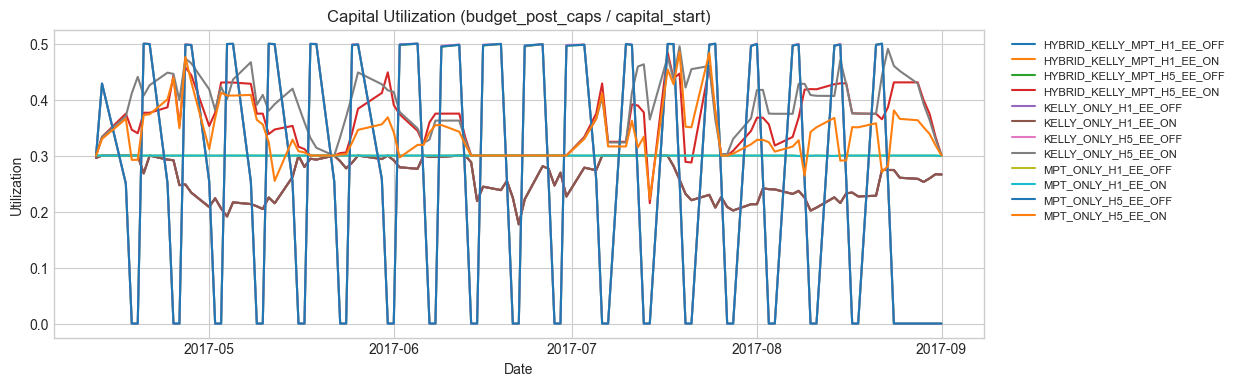

In [10]:
fig, ax = plt.subplots(figsize=(12, 4))
for mode, df in dfs.items():
    if {'budget_post_caps', 'capital_start'}.issubset(df.columns):
        utilization = df['budget_post_caps'] / df['capital_start']
        ax.plot(df['date'], utilization, label=mode)
ax.set_title('Capital Utilization (budget_post_caps / capital_start)')
ax.set_xlabel('Date')
ax.set_ylabel('Utilization')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()


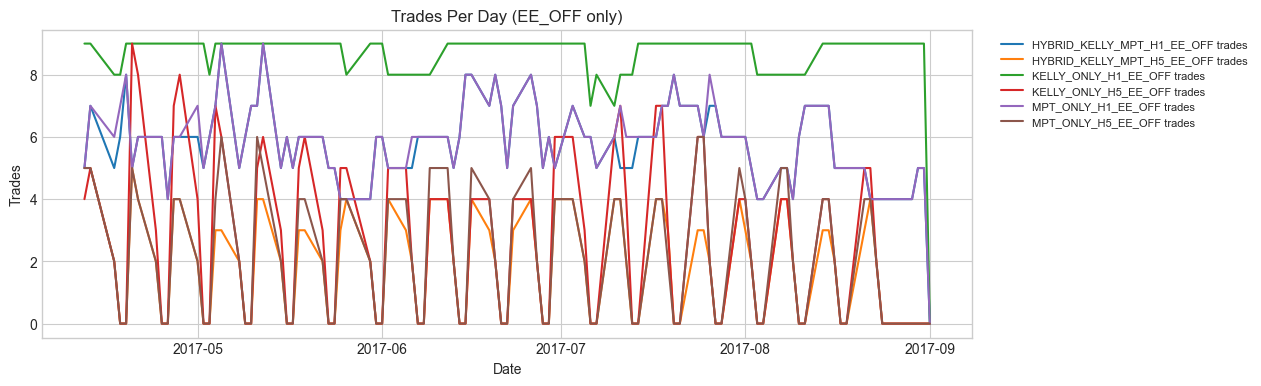

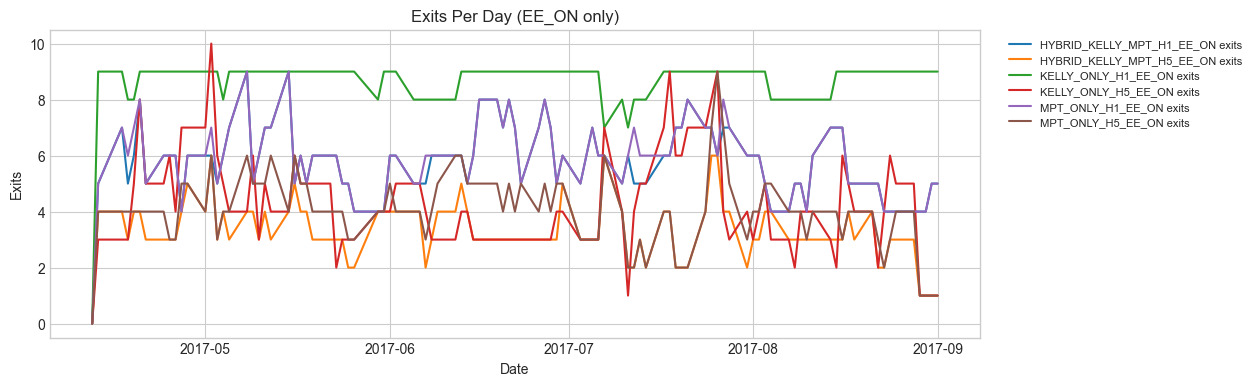

trades_made      exits     
                                  mean  sum  mean  sum
mode                                                  
HYBRID_KELLY_MPT_H1_EE_OFF        5.75  575  5.75  575
HYBRID_KELLY_MPT_H1_EE_ON         5.75  575  5.75  575
HYBRID_KELLY_MPT_H5_EE_OFF        1.80  180  1.80  180
HYBRID_KELLY_MPT_H5_EE_ON         3.29  329  3.29  329
KELLY_ONLY_H1_EE_OFF              8.66  866  8.66  866
KELLY_ONLY_H1_EE_ON               8.66  866  8.66  866
KELLY_ONLY_H5_EE_OFF              2.52  252  2.52  252
KELLY_ONLY_H5_EE_ON               4.24  424  4.24  424
MPT_ONLY_H1_EE_OFF                5.84  584  5.84  584
MPT_ONLY_H1_EE_ON                 5.84  584  5.84  584
MPT_ONLY_H5_EE_OFF                2.09  209  2.09  209
MPT_ONLY_H5_EE_ON                 4.01  401  4.01  401

In [11]:
trade_rows = []
for mode, df in dfs.items():
    if 'investments_made' in df.columns:
        inv = df['investments_made'].apply(_parse_maybe)
        trade_counts = inv.apply(lambda x: len(x) if isinstance(x, list) else 0)
    else:
        trade_counts = pd.Series(0, index=df.index)

    if 'exits_today' in df.columns:
        exits = df['exits_today'].apply(_parse_maybe)
        exit_counts = exits.apply(lambda x: len(x) if isinstance(x, list) else 0)
    else:
        exit_counts = pd.Series(0, index=df.index)

    trade_rows.append(pd.DataFrame({
        'date': df['date'],
        'mode': mode,
        'trades_made': trade_counts,
        'exits': exit_counts,
    }))

trades_df = pd.concat(trade_rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(12, 4))
for mode in trades_df['mode'].unique():
    df_mode = dfs.get(mode)
    if df_mode is not None and 'early_exit_enabled' in df_mode.columns:
        ee_on = bool(df_mode['early_exit_enabled'].iloc[0])
    else:
        ee_on = 'EE_ON' in str(mode)
    if ee_on:
        continue
    subset = trades_df[trades_df['mode'] == mode]
    ax.plot(subset['date'], subset['trades_made'], label=f'{mode} trades')
ax.set_title('Trades Per Day (EE_OFF only)')
ax.set_xlabel('Date')
ax.set_ylabel('Trades')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
for mode in trades_df['mode'].unique():
    df_mode = dfs.get(mode)
    if df_mode is not None and 'early_exit_enabled' in df_mode.columns:
        ee_on = bool(df_mode['early_exit_enabled'].iloc[0])
    else:
        ee_on = 'EE_ON' in str(mode)
    if not ee_on:
        continue
    subset = trades_df[trades_df['mode'] == mode]
    ax.plot(subset['date'], subset['exits'], label=f'{mode} exits')
ax.set_title('Exits Per Day (EE_ON only)')
ax.set_xlabel('Date')
ax.set_ylabel('Exits')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()

trades_summary = trades_df.groupby('mode')[['trades_made', 'exits']].agg(['mean', 'sum'])
trades_summary


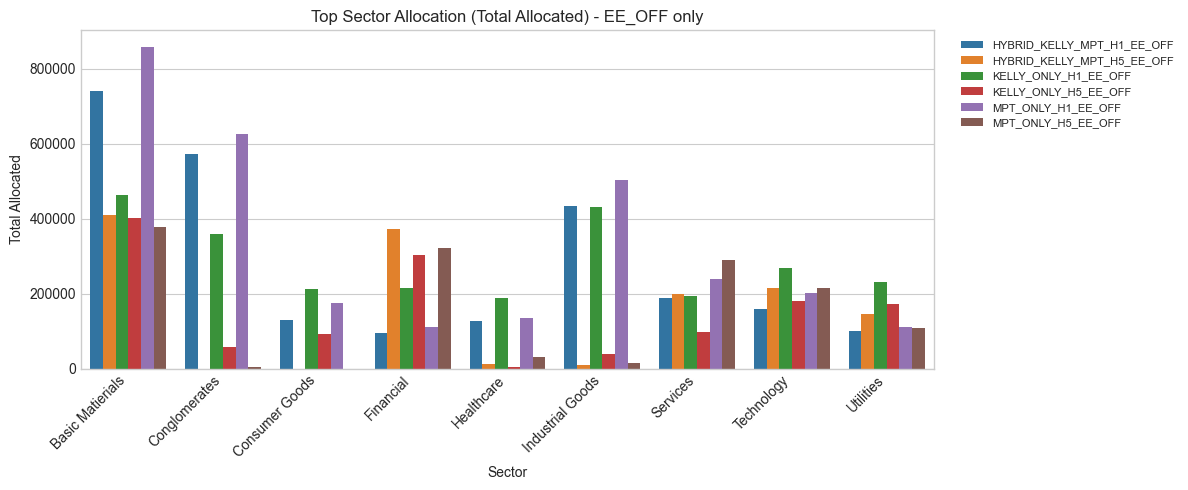

In [12]:
sector_rows = []
for mode, df in dfs.items():
    if 'investments_made' not in df.columns:
        continue
    if 'early_exit_enabled' in df.columns:
        ee_on = bool(df['early_exit_enabled'].iloc[0])
    else:
        ee_on = 'EE_ON' in str(mode)
    if ee_on:
        continue
    inv = df['investments_made'].apply(_parse_maybe)
    for day_list in inv:
        if not isinstance(day_list, list):
            continue
        for item in day_list:
            if not isinstance(item, dict):
                continue
            sector = item.get('sector', 'UNKNOWN')
            allocated = item.get('allocated_amount', item.get('invest', np.nan))
            sector_rows.append({'mode': mode, 'sector': sector, 'allocated': allocated})

sector_df = pd.DataFrame(sector_rows)
if not sector_df.empty:
    sector_summary = sector_df.groupby(['mode', 'sector'])['allocated'].sum().reset_index()
    top_sectors = sector_summary.groupby('sector')['allocated'].sum().nlargest(12).index
    plot_df = sector_summary[sector_summary['sector'].isin(top_sectors)]

    plt.figure(figsize=(12, 5))
    if _HAS_SEABORN:
        sns.barplot(data=plot_df, x='sector', y='allocated', hue='mode')
    else:
        for mode in plot_df['mode'].unique():
            subset = plot_df[plot_df['mode'] == mode]
            plt.bar(subset['sector'], subset['allocated'], alpha=0.6, label=mode)
    plt.title('Top Sector Allocation (Total Allocated) - EE_OFF only')
    plt.xlabel('Sector')
    plt.ylabel('Total Allocated')
    plt.xticks(rotation=45, ha='right')
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()

    sector_pivot = sector_summary.pivot(index='sector', columns='mode', values='allocated').fillna(0)
    sector_pivot


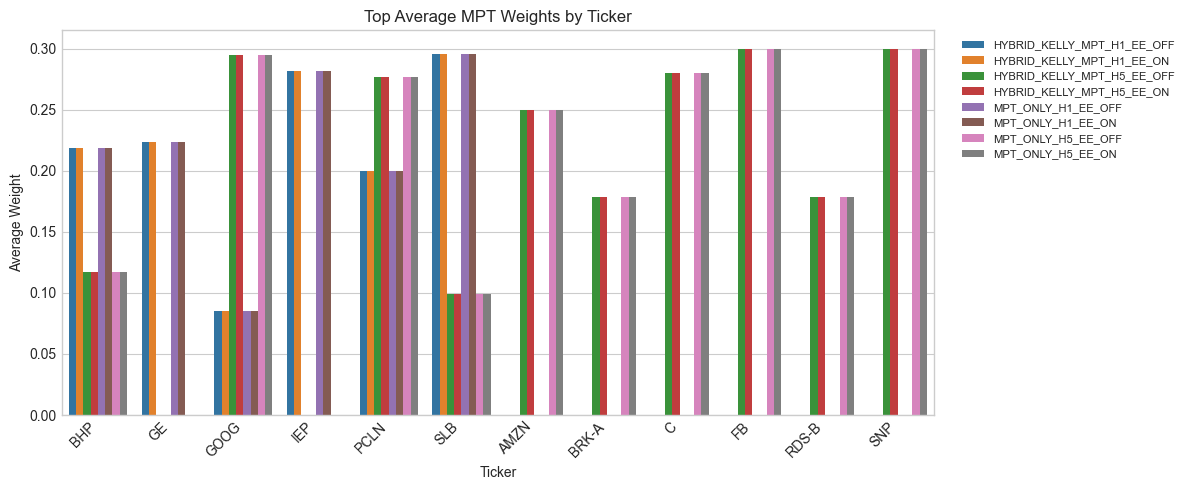

In [13]:
ticker_rows = []
for mode, df in dfs.items():
    if 'mpt_weights' not in df.columns:
        continue
    weights = df['mpt_weights'].apply(_parse_maybe)
    for weight_map in weights:
        if not isinstance(weight_map, dict):
            continue
        for ticker, w in weight_map.items():
            ticker_rows.append({'mode': mode, 'ticker': ticker, 'weight': float(w)})

ticker_df = pd.DataFrame(ticker_rows)
if not ticker_df.empty:
    ticker_summary = ticker_df.groupby(['mode', 'ticker'])['weight'].mean().reset_index()
    top_tickers = ticker_summary.groupby('ticker')['weight'].mean().nlargest(12).index
    plot_df = ticker_summary[ticker_summary['ticker'].isin(top_tickers)]

    plt.figure(figsize=(12, 5))
    if _HAS_SEABORN:
        sns.barplot(data=plot_df, x='ticker', y='weight', hue='mode')
    else:
        for mode in plot_df['mode'].unique():
            subset = plot_df[plot_df['mode'] == mode]
            plt.bar(subset['ticker'], subset['weight'], alpha=0.6, label=mode)
    plt.title('Top Average MPT Weights by Ticker')
    plt.xlabel('Ticker')
    plt.ylabel('Average Weight')
    plt.xticks(rotation=45, ha='right')
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()

    ticker_pivot = ticker_summary.pivot(index='ticker', columns='mode', values='weight').fillna(0)
    ticker_pivot


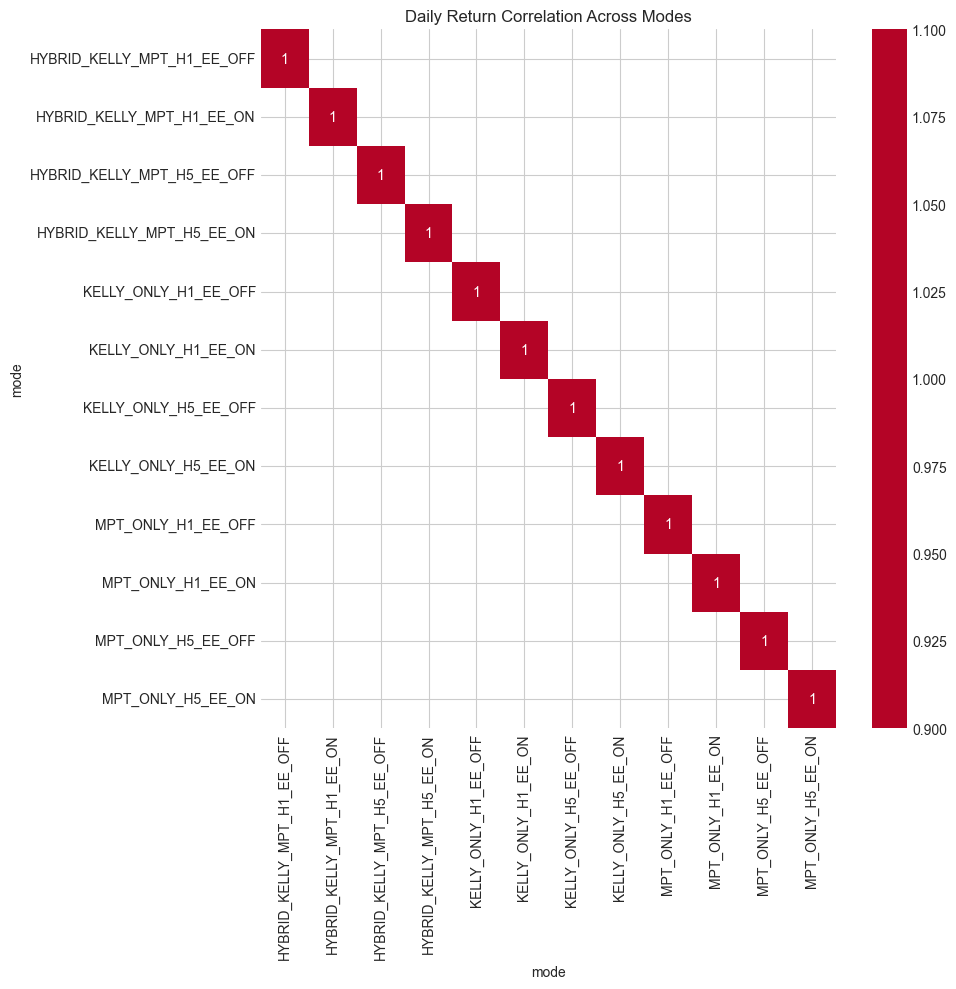

In [14]:
returns_pivot = returns_df.pivot(columns='mode', values='daily_return')
corr = returns_pivot.corr()

plt.figure(figsize=(10, 10))
if _HAS_SEABORN:
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
else:
    plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
    plt.yticks(range(len(corr.index)), corr.index)
    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')

plt.title('Daily Return Correlation Across Modes')
plt.tight_layout()
plt.show()


In [15]:
hyperparam_cols = [
    'H', 'initial_capital', 'initial_training_days', 'allow_overlap', 'seed', 'model_save_path',
    'min_sequence_length', 'max_sequence_length', 'kelly_fraction', 'sector_confidence_threshold',
    'retrain_interval', 'max_day_gap', 'mpt_window_days', 'mpt_lambda', 'mpt_ridge_eps',
    'mpt_max_weight', 'mpt_long_only', 'mpt_use_equal_fallback', 'mpt_only_budget_fraction',
    'max_total_utilization', 'max_new_daily_utilization', 'max_ticker_utilization',
    'max_sector_utilization', 'max_position_size', 'max_positions_per_ticker', 'min_trade_dollars',
    'kelly_trade_cap', 'drawdown_throttle_levels'
]

hyper_rows = []
for mode, df in dfs.items():
    row = {
        'mode': mode,
    }
    for col in hyperparam_cols:
        if col in df.columns:
            row[col] = df[col].iloc[0]
    hyper_rows.append(row)

hyper_df = pd.DataFrame(hyper_rows).set_index('mode')
hyper_df

# Summary table: trades, biggest winners/losers, average PnL, ROI, Sharpe
summary_rows = []

for mode, df in dfs.items():
    # Trade-level stats from exits_today
    exits_series = df['exits_today'].apply(_parse_maybe) if 'exits_today' in df.columns else pd.Series([], dtype=object)
    exit_trades = []
    for day_list in exits_series:
        if not isinstance(day_list, list):
            continue
        for item in day_list:
            if isinstance(item, dict):
                exit_trades.append(item)

    trades_df = pd.DataFrame(exit_trades)
    total_trades = len(trades_df)

    biggest_winner = np.nan
    biggest_loser = np.nan
    avg_pnl = np.nan
    if not trades_df.empty and 'pnl' in trades_df.columns:
        trades_df['pnl'] = pd.to_numeric(trades_df['pnl'], errors='coerce')
        biggest_winner = trades_df['pnl'].max()
        biggest_loser = trades_df['pnl'].min()
        avg_pnl = trades_df['pnl'].mean()

    # ROI + Sharpe from equity curve
    metrics = _metrics_from_df(df)

    summary_rows.append({
        'mode': mode,
        'total_trades': total_trades,
        'biggest_winner_pnl': biggest_winner,
        'biggest_loser_pnl': biggest_loser,
        'avg_trade_pnl': avg_pnl,
        'total_return': metrics.get('total_return'),
        'sharpe': metrics.get('sharpe'),
    })

summary_table = pd.DataFrame(summary_rows).set_index('mode')
summary_table


,total_trades,biggest_winner_pnl,biggest_loser_pnl,avg_trade_pnl,total_return,sharpe
mode,,,,,,
HYBRID_KELLY_MPT_H1_EE_OFF,575,288.900216,-327.813056,-0.031180,-0.000179,-0.002892
HYBRID_KELLY_MPT_H1_EE_ON,575,288.900216,-327.813056,-0.031180,-0.000179,-0.002892
HYBRID_KELLY_MPT_H5_EE_OFF,180,432.637812,-577.826662,21.883739,0.039391,2.213613
HYBRID_KELLY_MPT_H5_EE_ON,329,622.097399,-272.426328,19.966817,0.065691,4.418052
KELLY_ONLY_H1_EE_OFF,866,187.274474,-196.433560,1.117247,0.009675,1.035230
KELLY_ONLY_H1_EE_ON,866,187.274474,-196.433560,1.117247,0.009675,1.035230
KELLY_ONLY_H5_EE_OFF,252,335.469211,-446.055077,7.864056,0.019817,1.357714
KELLY_ONLY_H5_EE_ON,424,537.319824,-269.704451,14.023792,0.059461,4.377301
MPT_ONLY_H1_EE_OFF,584,333.249962,-340.478879,0.021497,0.000126,0.025604


In [16]:
# # Additional tables: top tickers/sectors winners/losers and summaries
# tables = {}

# for mode, df in dfs.items():
#     exits_series = df['exits_today'].apply(_parse_maybe) if 'exits_today' in df.columns else pd.Series([], dtype=object)
#     exit_trades = []
#     for day_list in exits_series:
#         if not isinstance(day_list, list):
#             continue
#         for item in day_list:
#             if isinstance(item, dict):
#                 exit_trades.append(item)

#     trades_df = pd.DataFrame(exit_trades)
#     if trades_df.empty:
#         continue

#     # Normalize fields
#     if 'pnl' in trades_df.columns:
#         trades_df['pnl'] = pd.to_numeric(trades_df['pnl'], errors='coerce')
#     if 'ticker' in trades_df.columns:
#         trades_df['ticker'] = trades_df['ticker'].astype(str)
#     if 'sector' in trades_df.columns:
#         trades_df['sector'] = trades_df['sector'].astype(str)

#     # Top/bottom trades overall
#     if 'pnl' in trades_df.columns:
#         tables[f'{mode} | Top 10 Trades (PnL)'] = trades_df.sort_values('pnl', ascending=False).head(10)
#         tables[f'{mode} | Bottom 10 Trades (PnL)'] = trades_df.sort_values('pnl', ascending=True).head(10)

#     # Ticker-level winners/losers
#     if {'ticker', 'pnl'}.issubset(trades_df.columns):
#         ticker_summary = trades_df.groupby('ticker')['pnl'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)
#         tables[f'{mode} | Top 10 Ticker Winners (Total PnL)'] = ticker_summary.head(10)
#         tables[f'{mode} | Top 10 Ticker Losers (Total PnL)'] = ticker_summary.tail(10).sort_values('sum')

#     # Sector-level winners/losers
#     if {'sector', 'pnl'}.issubset(trades_df.columns):
#         sector_summary = trades_df.groupby('sector')['pnl'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)
#         tables[f'{mode} | Top 10 Sector Winners (Total PnL)'] = sector_summary.head(10)
#         tables[f'{mode} | Top 10 Sector Losers (Total PnL)'] = sector_summary.tail(10).sort_values('sum')

# # Show all tables
# tables



# for name, table in tables.items():
#     print(f"\n=== {name} ===")
#     if isinstance(table, pd.DataFrame):
#         display(table)
#     else:
#         display(pd.DataFrame(table))


In [17]:
# ROI table (Total Return %)
roi_rows = []
for mode, df in dfs.items():
    metrics = _metrics_from_df(df)
    roi_rows.append({
        'mode': mode,
        'total_return': metrics.get('total_return'),
        'total_return_pct': (metrics.get('total_return') or np.nan) * 100.0,
        'CAGR': metrics.get('CAGR'),
    })

roi_table = pd.DataFrame(roi_rows).set_index('mode').sort_values('total_return', ascending=False)
roi_table


,total_return,total_return_pct,CAGR
mode,,,
HYBRID_KELLY_MPT_H5_EE_ON,0.065691,6.569083,0.173899
KELLY_ONLY_H5_EE_ON,0.059461,5.946088,0.156682
MPT_ONLY_H5_EE_ON,0.048130,4.812978,0.125760
HYBRID_KELLY_MPT_H5_EE_OFF,0.039391,3.939073,0.102257
MPT_ONLY_H5_EE_OFF,0.030311,3.031141,0.078154
KELLY_ONLY_H5_EE_OFF,0.019817,1.981742,0.050695
KELLY_ONLY_H1_EE_OFF,0.009675,0.967536,0.024561
KELLY_ONLY_H1_EE_ON,0.009675,0.967536,0.024561
MPT_ONLY_H1_EE_OFF,0.000126,0.012554,0.000316


In [18]:
# Combined table: ROI, Sharpe, avg trade size, avg trade PnL + hyperparameters
rows = []

for mode, df in dfs.items():
    metrics = _metrics_from_df(df)

    exits_series = df['exits_today'].apply(_parse_maybe) if 'exits_today' in df.columns else pd.Series([], dtype=object)
    exit_trades = []
    for day_list in exits_series:
        if not isinstance(day_list, list):
            continue
        for item in day_list:
            if isinstance(item, dict):
                exit_trades.append(item)

    trades_df = pd.DataFrame(exit_trades)
    avg_trade_size = np.nan
    avg_trade_pnl = np.nan
    if not trades_df.empty:
        if 'allocated_amount' in trades_df.columns:
            trades_df['allocated_amount'] = pd.to_numeric(trades_df['allocated_amount'], errors='coerce')
            avg_trade_size = trades_df['allocated_amount'].mean()
        if 'pnl' in trades_df.columns:
            trades_df['pnl'] = pd.to_numeric(trades_df['pnl'], errors='coerce')
            avg_trade_pnl = trades_df['pnl'].mean()

    row = {
        'mode': mode,
        'ROI': metrics.get('total_return'),
        'ROI_pct': (metrics.get('total_return') or np.nan) * 100.0,
        'Sharpe': metrics.get('sharpe'),
        'Avg_Trade_Size': avg_trade_size,
        'Avg_Trade_PnL': avg_trade_pnl,
    }

    # Attach hyperparameters
    if 'hyper_df' in globals():
        if mode in hyper_df.index:
            for col in hyper_df.columns:
                row[col] = hyper_df.loc[mode, col]
    else:
        # fallback: use first row from df if hyper_df not available
        for col in hyperparam_cols if 'hyperparam_cols' in globals() else []:
            if col in df.columns:
                row[col] = df[col].iloc[0]

    rows.append(row)

combined_table = pd.DataFrame(rows).set_index('mode')
combined_table


,ROI,ROI_pct,Sharpe,Avg_Trade_Size,Avg_Trade_PnL,H,initial_capital,initial_training_days,allow_overlap,seed,...,mpt_only_budget_fraction,max_total_utilization,max_new_daily_utilization,max_ticker_utilization,max_sector_utilization,max_position_size,max_positions_per_ticker,min_trade_dollars,kelly_trade_cap,drawdown_throttle_levels
mode,,,,,,,,,,,,,,,,,,,,,
HYBRID_KELLY_MPT_H1_EE_OFF,-0.000179,-0.017928,-0.002892,4430.822084,-0.031180,1,100000.0,1109,True,42,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"
HYBRID_KELLY_MPT_H1_EE_ON,-0.000179,-0.017928,-0.002892,4430.822084,-0.031180,1,100000.0,1109,True,42,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"
HYBRID_KELLY_MPT_H5_EE_OFF,0.039391,3.939073,2.213613,7594.239694,21.883739,5,100000.0,1109,True,42,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"
HYBRID_KELLY_MPT_H5_EE_ON,0.065691,6.569083,4.418052,8588.243442,19.966817,5,100000.0,1109,True,42,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"
KELLY_ONLY_H1_EE_OFF,0.009675,0.967536,1.035230,2962.152759,1.117247,1,100000.0,1109,True,42,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"
KELLY_ONLY_H1_EE_ON,0.009675,0.967536,1.035230,2962.152759,1.117247,1,100000.0,1109,True,42,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"
KELLY_ONLY_H5_EE_OFF,0.019817,1.981742,1.357714,5354.967069,7.864056,5,100000.0,1109,True,42,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"
KELLY_ONLY_H5_EE_ON,0.059461,5.946088,4.377301,6805.733291,14.023792,5,100000.0,1109,True,42,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"
MPT_ONLY_H1_EE_OFF,0.000126,0.012554,0.025604,5079.554263,0.021497,1,100000.0,1109,True,42,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"


## Binary with Meta Features

In [19]:
RESULTS_DIR_META = Path('../results/simulation/binary')
csv_paths = sorted(RESULTS_DIR_META.glob('*.csv'))
if not csv_paths:
    raise FileNotFoundError(f'No CSVs found in {RESULTS_DIR_META.resolve()}')

dfs = {}
for path in csv_paths:
    df = pd.read_csv(path)
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date')

    # Use filename stem as the primary label to avoid collisions
    mode = path.stem
    df['mode'] = mode
    dfs[mode] = df

list(dfs.keys())


['HYBRID_KELLY_MPT_H1_EE_OFF',
 'HYBRID_KELLY_MPT_H1_EE_ON',
 'HYBRID_KELLY_MPT_H5_EE_OFF',
 'HYBRID_KELLY_MPT_H5_EE_ON',
 'KELLY_ONLY_H1_EE_OFF',
 'KELLY_ONLY_H1_EE_ON',
 'KELLY_ONLY_H5_EE_OFF',
 'KELLY_ONLY_H5_EE_ON',
 'MPT_ONLY_H1_EE_OFF',
 'MPT_ONLY_H1_EE_ON',
 'MPT_ONLY_H5_EE_OFF',
 'MPT_ONLY_H5_EE_ON']

In [20]:
summary_rows = []
for mode, df in dfs.items():
    metrics = _metrics_from_df(df)
    metrics['mode'] = mode
    summary_rows.append(metrics)

summary_df = pd.DataFrame(summary_rows).set_index('mode').sort_values('total_return', ascending=False)
summary_df


,days,start_equity,end_equity,total_return,CAGR,volatility,sharpe,sortino,max_drawdown,win_rate,avg_win,avg_loss,profit_factor
mode,,,,,,,,,,,,,
MPT_ONLY_H5_EE_OFF,100,100000.0,112465.136644,0.124651,0.344513,0.068816,4.338045,9.737885,-0.023648,0.32,0.005310,-0.002058,3.302654
HYBRID_KELLY_MPT_H5_EE_OFF,100,100000.0,108664.742333,0.086647,0.232944,0.049461,4.259872,8.427138,-0.019556,0.33,0.003885,-0.001858,2.874500
MPT_ONLY_H5_EE_ON,100,100000.0,103572.041087,0.035720,0.092474,0.049452,1.813253,3.202592,-0.022019,0.51,0.002630,-0.002142,1.361097
KELLY_ONLY_H5_EE_OFF,100,100000.0,102762.755288,0.027628,0.071090,0.038783,1.790184,2.800652,-0.016096,0.27,0.002988,-0.001771,1.518515
HYBRID_KELLY_MPT_H5_EE_ON,100,100000.0,102711.469374,0.027115,0.069744,0.048840,1.404741,2.211263,-0.027465,0.49,0.002545,-0.002030,1.279344
KELLY_ONLY_H5_EE_ON,100,100000.0,101389.883705,0.013899,0.035396,0.033830,1.045031,1.357317,-0.019302,0.56,0.001554,-0.001698,1.192196
KELLY_ONLY_H1_EE_OFF,100,100000.0,101051.216414,0.010512,0.026703,0.021154,1.256275,1.713250,-0.010215,0.52,0.001056,-0.000944,1.237702
KELLY_ONLY_H1_EE_ON,100,100000.0,101051.216414,0.010512,0.026703,0.021154,1.256275,1.713250,-0.010215,0.52,0.001056,-0.000944,1.237702
HYBRID_KELLY_MPT_H1_EE_OFF,100,100000.0,100249.342647,0.002493,0.006295,0.022812,0.286397,0.397999,-0.011828,0.51,0.001098,-0.001112,1.048554


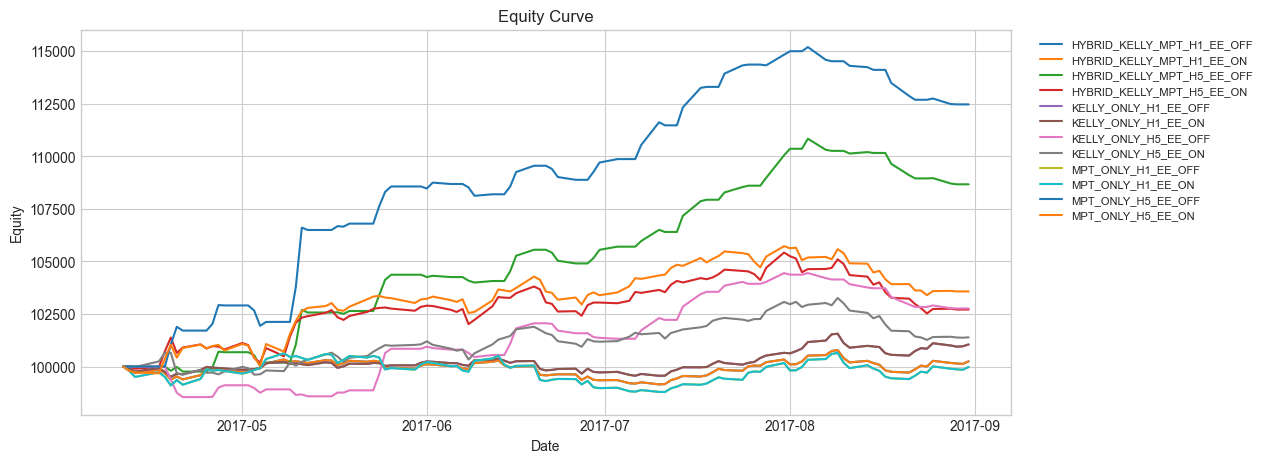

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
for mode, df in dfs.items():
    if 'equity_end' in df.columns:
        ax.plot(df['date'], df['equity_end'], label=mode)
ax.set_title('Equity Curve')
ax.set_xlabel('Date')
ax.set_ylabel('Equity')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()


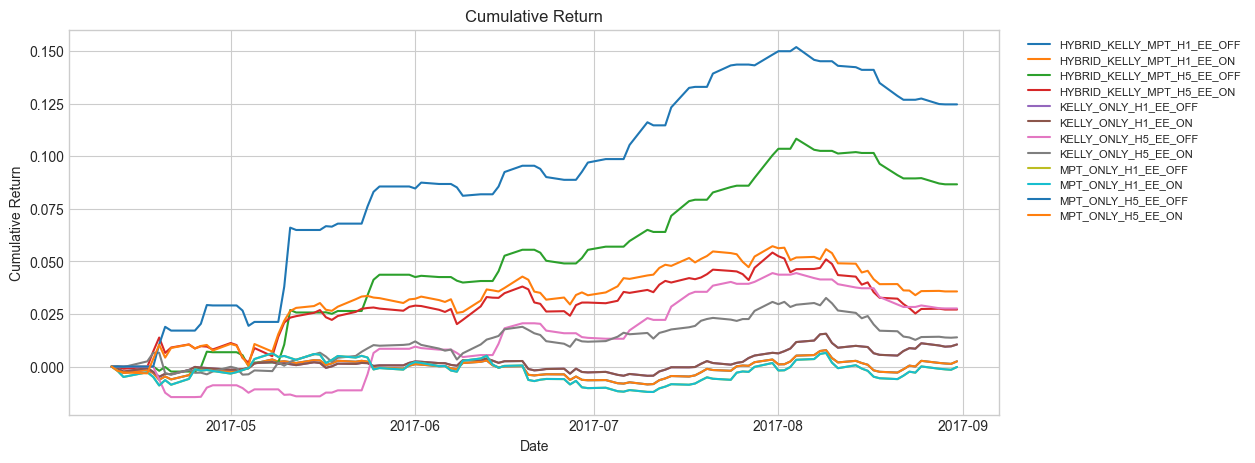

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
for mode, df in dfs.items():
    if 'equity_end' in df.columns and 'equity_start' in df.columns:
        base = df['equity_start'].iloc[0]
        ax.plot(df['date'], df['equity_end'] / base - 1.0, label=mode)
ax.set_title('Cumulative Return')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()


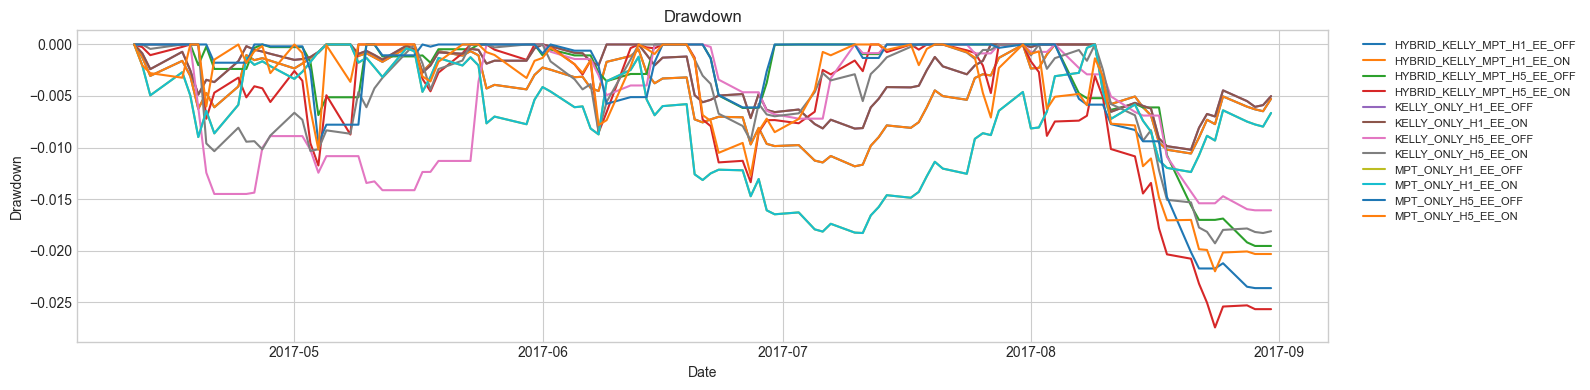

In [23]:
fig, ax = plt.subplots(figsize=(16, 4))
for mode, df in dfs.items():
    if 'equity_end' in df.columns:
        roll_max = df['equity_end'].cummax()
        drawdown = df['equity_end'] / roll_max - 1.0
        ax.plot(df['date'], drawdown, label=mode)
ax.set_title('Drawdown')
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


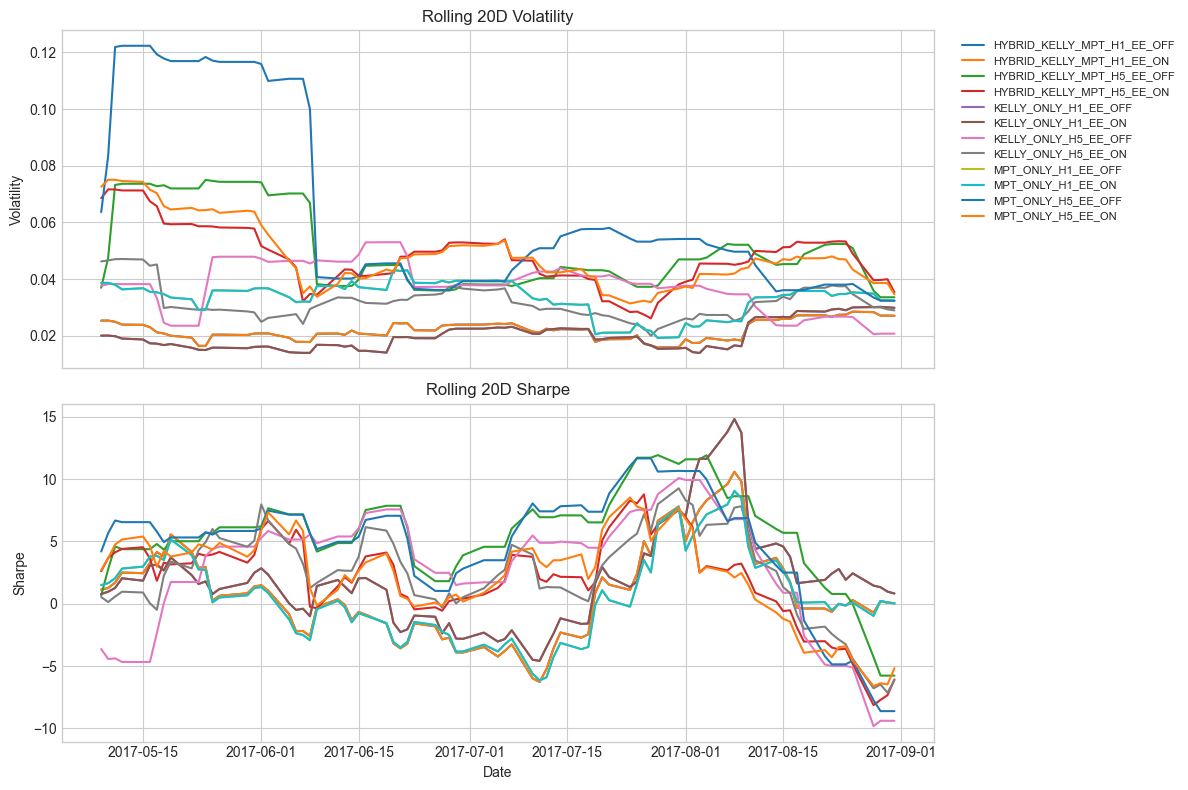

In [24]:
window = 20
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for mode, df in dfs.items():
    df = _ensure_returns(df)
    rets = df['daily_return'].astype(float).fillna(0.0)
    roll_vol = rets.rolling(window).std() * np.sqrt(252)
    roll_sharpe = rets.rolling(window).mean() / (rets.rolling(window).std() + 1e-12) * np.sqrt(252)
    axes[0].plot(df['date'], roll_vol, label=mode)
    axes[1].plot(df['date'], roll_sharpe, label=mode)

axes[0].set_title(f'Rolling {window}D Volatility')
axes[0].set_ylabel('Volatility')
axes[1].set_title(f'Rolling {window}D Sharpe')
axes[1].set_ylabel('Sharpe')
axes[1].set_xlabel('Date')
axes[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


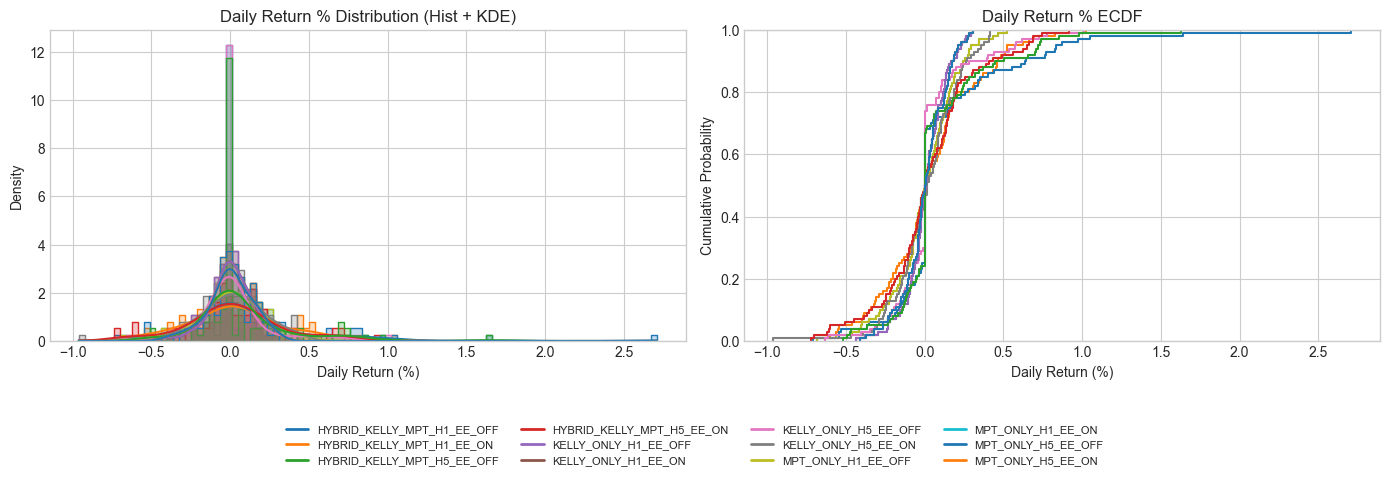

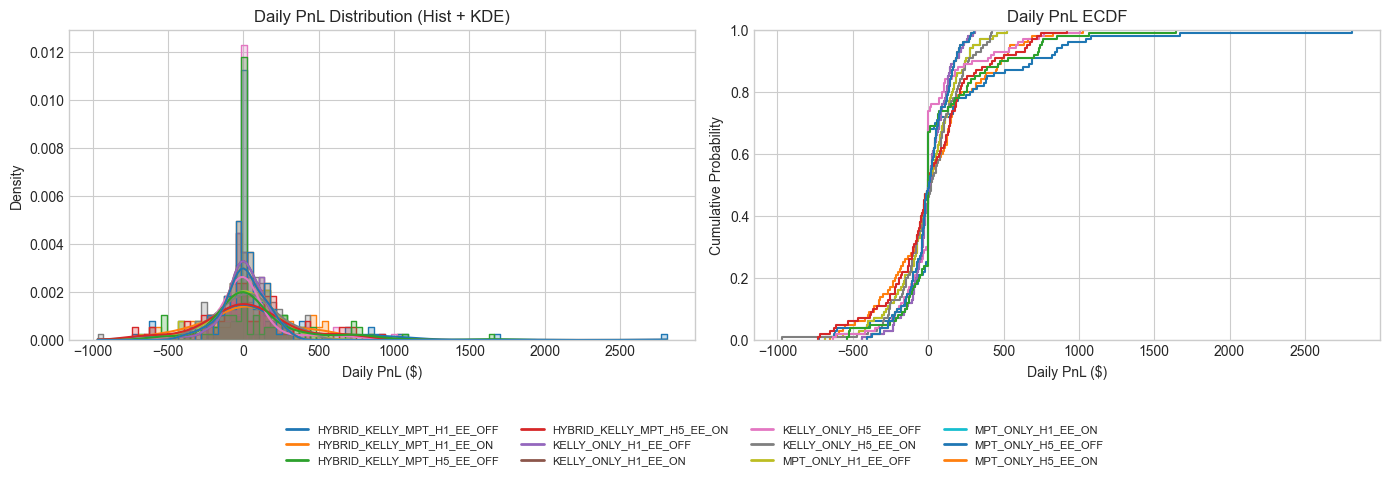

,max_abs_diff,mean_abs_diff,csv_nonnull,calc_nonnull
mode,,,,
HYBRID_KELLY_MPT_H1_EE_OFF,4.790005e-16,1.583339e-16,100,100
HYBRID_KELLY_MPT_H1_EE_ON,4.790005e-16,1.583339e-16,100,100
HYBRID_KELLY_MPT_H5_EE_OFF,3.864097e-16,7.212628e-17,100,100
HYBRID_KELLY_MPT_H5_EE_ON,4.310788e-16,1.150542e-16,100,100
KELLY_ONLY_H1_EE_OFF,5.423179e-16,1.617311e-16,100,100
KELLY_ONLY_H1_EE_ON,5.423179e-16,1.617311e-16,100,100
KELLY_ONLY_H5_EE_OFF,4.209957e-16,7.541968e-17,100,100
KELLY_ONLY_H5_EE_ON,4.796510e-16,1.290468e-16,100,100
MPT_ONLY_H1_EE_OFF,4.254409e-16,1.401968e-16,100,100


In [25]:
all_returns = []
pnl_rows = []
diag_rows = []
for mode, df in dfs.items():
    df = df.copy()
    csv_returns = df['daily_return'].astype(float) if 'daily_return' in df.columns else pd.Series(np.nan, index=df.index)
    calc_returns = _calc_daily_return(df).astype(float)

    diff = (csv_returns - calc_returns).abs()
    diag_rows.append({
        'mode': mode,
        'max_abs_diff': diff.max(),
        'mean_abs_diff': diff.mean(),
        'csv_nonnull': csv_returns.notna().sum(),
        'calc_nonnull': calc_returns.notna().sum(),
    })

    all_returns.append(pd.DataFrame({'mode': mode, 'daily_return': calc_returns}))
    if 'daily_pnl_realized' in df.columns:
        pnl_rows.append(pd.DataFrame({'mode': mode, 'daily_pnl': df['daily_pnl_realized'].astype(float)}))

returns_df = pd.concat(all_returns, ignore_index=True)
returns_df = returns_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['daily_return'])
returns_df['daily_return_pct'] = returns_df['daily_return'] * 100.0

pnl_df = pd.concat(pnl_rows, ignore_index=True) if pnl_rows else pd.DataFrame(columns=['mode', 'daily_pnl'])
pnl_df = pnl_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['daily_pnl'])

# Build a color map that covers all modes present
mode_order = sorted(returns_df['mode'].unique())
if _HAS_SEABORN:
    palette = sns.color_palette('tab10', n_colors=max(len(mode_order), 1))
else:
    palette = plt.cm.tab10.colors if len(mode_order) <= 10 else plt.cm.tab20.colors
mode_color_map = {mode: palette[i % len(palette)] for i, mode in enumerate(mode_order)}

# -------------------- RETURNS FIGURE --------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Returns: histogram + KDE
if _HAS_SEABORN:
    sns.histplot(data=returns_df, x='daily_return_pct', hue='mode', element='step', stat='density',
                 common_norm=False, kde=True, palette=mode_color_map, ax=axes[0], legend=False)
else:
    for mode in returns_df['mode'].unique():
        subset = returns_df[returns_df['mode'] == mode]['daily_return_pct']
        axes[0].hist(subset, bins=30, alpha=0.35, label=mode, density=True, color=mode_color_map.get(mode))
axes[0].set_title('Daily Return % Distribution (Hist + KDE)')
axes[0].set_xlabel('Daily Return (%)')
axes[0].set_ylabel('Density')

# Returns: ECDF
if _HAS_SEABORN:
    sns.ecdfplot(data=returns_df, x='daily_return_pct', hue='mode', palette=mode_color_map, ax=axes[1], legend=False)
else:
    for mode in returns_df['mode'].unique():
        subset = np.sort(returns_df[returns_df['mode'] == mode]['daily_return_pct'].values)
        y = np.arange(1, len(subset) + 1) / len(subset)
        axes[1].plot(subset, y, label=mode, color=mode_color_map.get(mode))
axes[1].set_title('Daily Return % ECDF')
axes[1].set_xlabel('Daily Return (%)')
axes[1].set_ylabel('Cumulative Probability')

# Shared legend below the returns plots
handles = [plt.Line2D([0], [0], color=mode_color_map[m], lw=2) for m in mode_order]
fig.legend(handles, mode_order, loc='upper center', bbox_to_anchor=(0.5, -0.05),
           ncol=min(len(mode_order), 4), frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# -------------------- PNL FIGURE --------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# PnL: histogram + KDE
if not pnl_df.empty:
    if _HAS_SEABORN:
        sns.histplot(data=pnl_df, x='daily_pnl', hue='mode', element='step', stat='density',
                     common_norm=False, kde=True, palette=mode_color_map, ax=axes[0], legend=False)
    else:
        for mode in pnl_df['mode'].unique():
            subset = pnl_df[pnl_df['mode'] == mode]['daily_pnl']
            axes[0].hist(subset, bins=30, alpha=0.35, label=mode, density=True, color=mode_color_map.get(mode))
    axes[0].set_title('Daily PnL Distribution (Hist + KDE)')
    axes[0].set_xlabel('Daily PnL ($)')
    axes[0].set_ylabel('Density')
else:
    axes[0].text(0.5, 0.5, 'No daily_pnl_realized column found', ha='center', va='center')
    axes[0].set_axis_off()

# PnL: ECDF
if not pnl_df.empty:
    if _HAS_SEABORN:
        sns.ecdfplot(data=pnl_df, x='daily_pnl', hue='mode', palette=mode_color_map, ax=axes[1], legend=False)
    else:
        for mode in pnl_df['mode'].unique():
            subset = np.sort(pnl_df[pnl_df['mode'] == mode]['daily_pnl'].values)
            y = np.arange(1, len(subset) + 1) / len(subset)
            axes[1].plot(subset, y, label=mode, color=mode_color_map.get(mode))
    axes[1].set_title('Daily PnL ECDF')
    axes[1].set_xlabel('Daily PnL ($)')
    axes[1].set_ylabel('Cumulative Probability')
else:
    axes[1].text(0.5, 0.5, 'No daily_pnl_realized column found', ha='center', va='center')
    axes[1].set_axis_off()

# Shared legend below the pnl plots
if not pnl_df.empty:
    fig.legend(handles, mode_order, loc='upper center', bbox_to_anchor=(0.5, -0.05),
               ncol=min(len(mode_order), 4), frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

pd.DataFrame(diag_rows).set_index('mode')


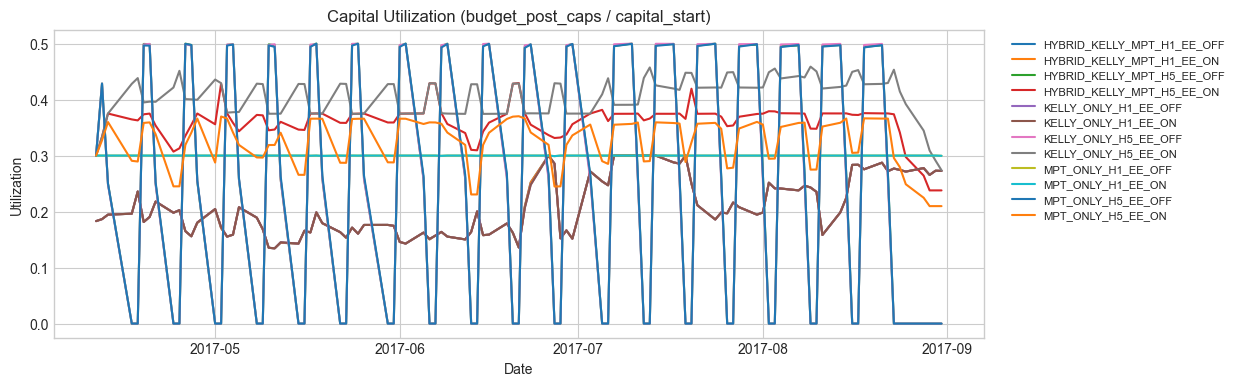

In [26]:
fig, ax = plt.subplots(figsize=(12, 4))
for mode, df in dfs.items():
    if {'budget_post_caps', 'capital_start'}.issubset(df.columns):
        utilization = df['budget_post_caps'] / df['capital_start']
        ax.plot(df['date'], utilization, label=mode)
ax.set_title('Capital Utilization (budget_post_caps / capital_start)')
ax.set_xlabel('Date')
ax.set_ylabel('Utilization')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()


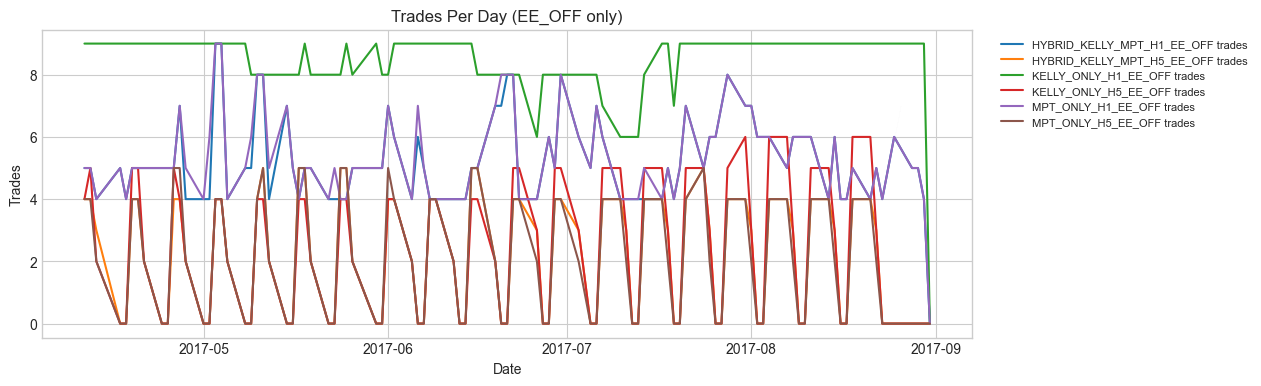

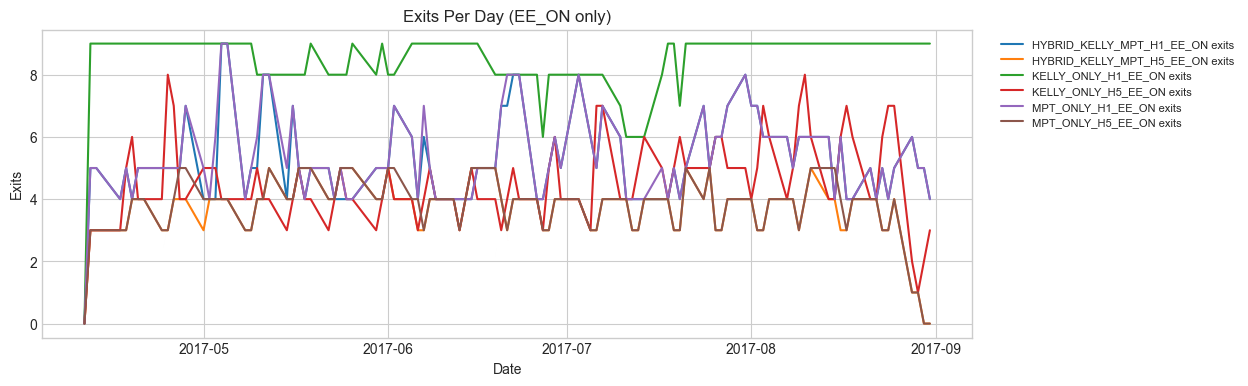

trades_made      exits     
                                  mean  sum  mean  sum
mode                                                  
HYBRID_KELLY_MPT_H1_EE_OFF        5.24  524  5.24  524
HYBRID_KELLY_MPT_H1_EE_ON         5.24  524  5.24  524
HYBRID_KELLY_MPT_H5_EE_OFF        2.08  208  2.08  208
HYBRID_KELLY_MPT_H5_EE_ON         3.66  366  3.66  366
KELLY_ONLY_H1_EE_OFF              8.44  844  8.44  844
KELLY_ONLY_H1_EE_ON               8.44  844  8.44  844
KELLY_ONLY_H5_EE_OFF              2.26  226  2.26  226
KELLY_ONLY_H5_EE_ON               4.53  453  4.53  453
MPT_ONLY_H1_EE_OFF                5.33  533  5.33  533
MPT_ONLY_H1_EE_ON                 5.33  533  5.33  533
MPT_ONLY_H5_EE_OFF                2.01  201  2.01  201
MPT_ONLY_H5_EE_ON                 3.74  374  3.74  374

In [27]:
trade_rows = []
for mode, df in dfs.items():
    if 'investments_made' in df.columns:
        inv = df['investments_made'].apply(_parse_maybe)
        trade_counts = inv.apply(lambda x: len(x) if isinstance(x, list) else 0)
    else:
        trade_counts = pd.Series(0, index=df.index)

    if 'exits_today' in df.columns:
        exits = df['exits_today'].apply(_parse_maybe)
        exit_counts = exits.apply(lambda x: len(x) if isinstance(x, list) else 0)
    else:
        exit_counts = pd.Series(0, index=df.index)

    trade_rows.append(pd.DataFrame({
        'date': df['date'],
        'mode': mode,
        'trades_made': trade_counts,
        'exits': exit_counts,
    }))

trades_df = pd.concat(trade_rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(12, 4))
for mode in trades_df['mode'].unique():
    df_mode = dfs.get(mode)
    if df_mode is not None and 'early_exit_enabled' in df_mode.columns:
        ee_on = bool(df_mode['early_exit_enabled'].iloc[0])
    else:
        ee_on = 'EE_ON' in str(mode)
    if ee_on:
        continue
    subset = trades_df[trades_df['mode'] == mode]
    ax.plot(subset['date'], subset['trades_made'], label=f'{mode} trades')
ax.set_title('Trades Per Day (EE_OFF only)')
ax.set_xlabel('Date')
ax.set_ylabel('Trades')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
for mode in trades_df['mode'].unique():
    df_mode = dfs.get(mode)
    if df_mode is not None and 'early_exit_enabled' in df_mode.columns:
        ee_on = bool(df_mode['early_exit_enabled'].iloc[0])
    else:
        ee_on = 'EE_ON' in str(mode)
    if not ee_on:
        continue
    subset = trades_df[trades_df['mode'] == mode]
    ax.plot(subset['date'], subset['exits'], label=f'{mode} exits')
ax.set_title('Exits Per Day (EE_ON only)')
ax.set_xlabel('Date')
ax.set_ylabel('Exits')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()

trades_summary = trades_df.groupby('mode')[['trades_made', 'exits']].agg(['mean', 'sum'])
trades_summary


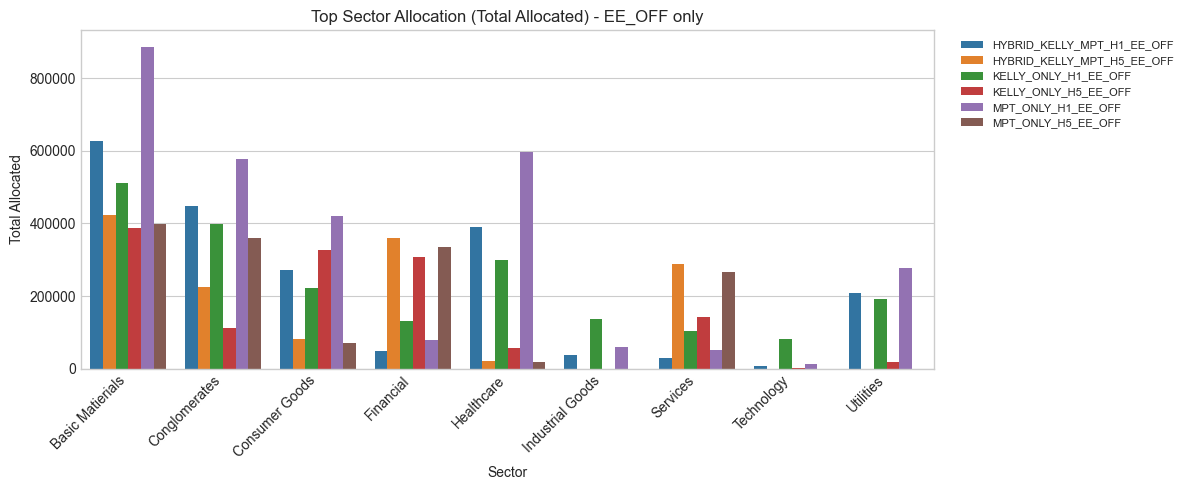

In [28]:
sector_rows = []
for mode, df in dfs.items():
    if 'investments_made' not in df.columns:
        continue
    if 'early_exit_enabled' in df.columns:
        ee_on = bool(df['early_exit_enabled'].iloc[0])
    else:
        ee_on = 'EE_ON' in str(mode)
    if ee_on:
        continue
    inv = df['investments_made'].apply(_parse_maybe)
    for day_list in inv:
        if not isinstance(day_list, list):
            continue
        for item in day_list:
            if not isinstance(item, dict):
                continue
            sector = item.get('sector', 'UNKNOWN')
            allocated = item.get('allocated_amount', item.get('invest', np.nan))
            sector_rows.append({'mode': mode, 'sector': sector, 'allocated': allocated})

sector_df = pd.DataFrame(sector_rows)
if not sector_df.empty:
    sector_summary = sector_df.groupby(['mode', 'sector'])['allocated'].sum().reset_index()
    top_sectors = sector_summary.groupby('sector')['allocated'].sum().nlargest(12).index
    plot_df = sector_summary[sector_summary['sector'].isin(top_sectors)]

    plt.figure(figsize=(12, 5))
    if _HAS_SEABORN:
        sns.barplot(data=plot_df, x='sector', y='allocated', hue='mode')
    else:
        for mode in plot_df['mode'].unique():
            subset = plot_df[plot_df['mode'] == mode]
            plt.bar(subset['sector'], subset['allocated'], alpha=0.6, label=mode)
    plt.title('Top Sector Allocation (Total Allocated) - EE_OFF only')
    plt.xlabel('Sector')
    plt.ylabel('Total Allocated')
    plt.xticks(rotation=45, ha='right')
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()

    sector_pivot = sector_summary.pivot(index='sector', columns='mode', values='allocated').fillna(0)
    sector_pivot


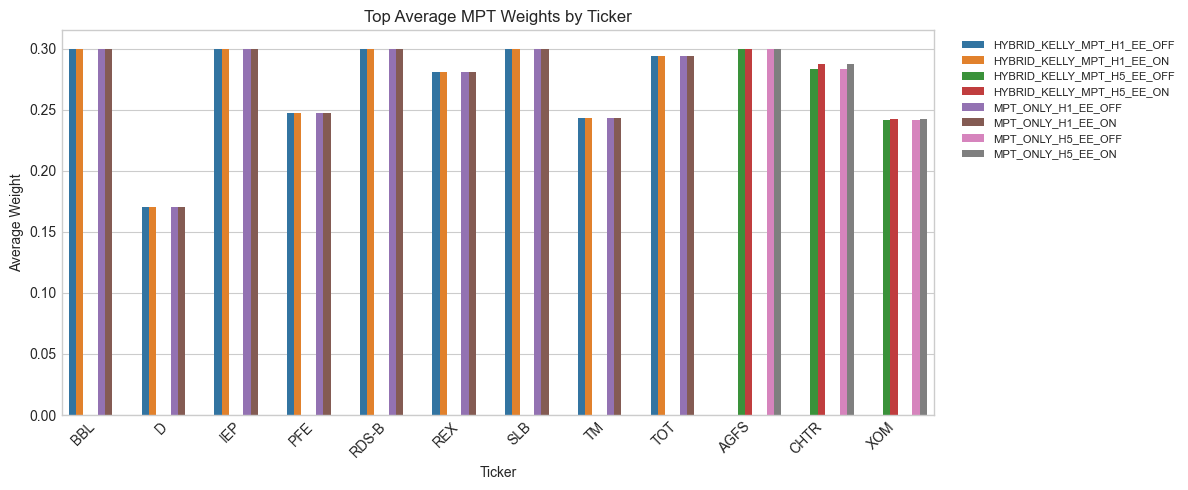

In [29]:
ticker_rows = []
for mode, df in dfs.items():
    if 'mpt_weights' not in df.columns:
        continue
    weights = df['mpt_weights'].apply(_parse_maybe)
    for weight_map in weights:
        if not isinstance(weight_map, dict):
            continue
        for ticker, w in weight_map.items():
            ticker_rows.append({'mode': mode, 'ticker': ticker, 'weight': float(w)})

ticker_df = pd.DataFrame(ticker_rows)
if not ticker_df.empty:
    ticker_summary = ticker_df.groupby(['mode', 'ticker'])['weight'].mean().reset_index()
    top_tickers = ticker_summary.groupby('ticker')['weight'].mean().nlargest(12).index
    plot_df = ticker_summary[ticker_summary['ticker'].isin(top_tickers)]

    plt.figure(figsize=(12, 5))
    if _HAS_SEABORN:
        sns.barplot(data=plot_df, x='ticker', y='weight', hue='mode')
    else:
        for mode in plot_df['mode'].unique():
            subset = plot_df[plot_df['mode'] == mode]
            plt.bar(subset['ticker'], subset['weight'], alpha=0.6, label=mode)
    plt.title('Top Average MPT Weights by Ticker')
    plt.xlabel('Ticker')
    plt.ylabel('Average Weight')
    plt.xticks(rotation=45, ha='right')
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()

    ticker_pivot = ticker_summary.pivot(index='ticker', columns='mode', values='weight').fillna(0)
    ticker_pivot


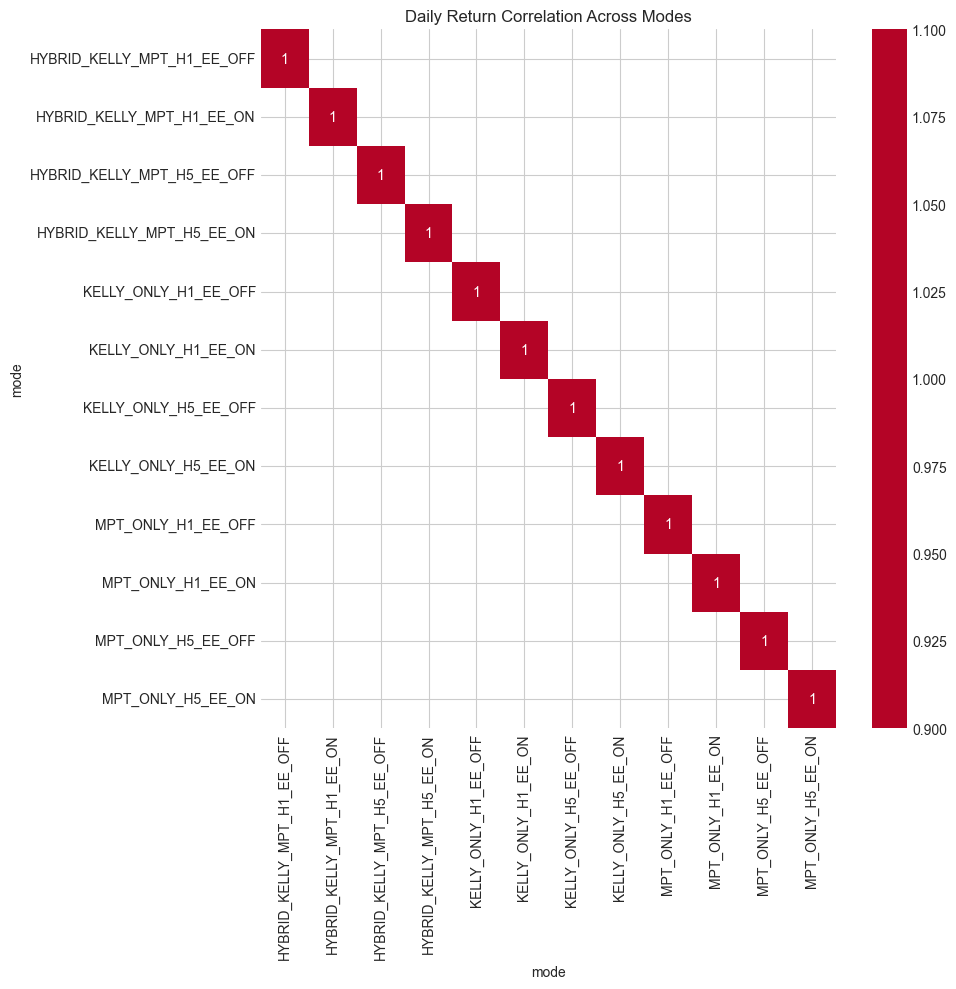

In [30]:
returns_pivot = returns_df.pivot(columns='mode', values='daily_return')
corr = returns_pivot.corr()

plt.figure(figsize=(10, 10))
if _HAS_SEABORN:
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
else:
    plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
    plt.yticks(range(len(corr.index)), corr.index)
    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')

plt.title('Daily Return Correlation Across Modes')
plt.tight_layout()
plt.show()


In [31]:
hyperparam_cols = [
    'H', 'initial_capital', 'initial_training_days', 'allow_overlap', 'seed', 'model_save_path',
    'min_sequence_length', 'max_sequence_length', 'kelly_fraction', 'sector_confidence_threshold',
    'retrain_interval', 'max_day_gap', 'mpt_window_days', 'mpt_lambda', 'mpt_ridge_eps',
    'mpt_max_weight', 'mpt_long_only', 'mpt_use_equal_fallback', 'mpt_only_budget_fraction',
    'max_total_utilization', 'max_new_daily_utilization', 'max_ticker_utilization',
    'max_sector_utilization', 'max_position_size', 'max_positions_per_ticker', 'min_trade_dollars',
    'kelly_trade_cap', 'drawdown_throttle_levels'
]

hyper_rows = []
for mode, df in dfs.items():
    row = {
        'mode': mode,
    }
    for col in hyperparam_cols:
        if col in df.columns:
            row[col] = df[col].iloc[0]
    hyper_rows.append(row)

hyper_df = pd.DataFrame(hyper_rows).set_index('mode')
hyper_df




,H,initial_capital,initial_training_days,allow_overlap,seed,model_save_path,min_sequence_length,max_sequence_length,kelly_fraction,sector_confidence_threshold,...,mpt_only_budget_fraction,max_total_utilization,max_new_daily_utilization,max_ticker_utilization,max_sector_utilization,max_position_size,max_positions_per_ticker,min_trade_dollars,kelly_trade_cap,drawdown_throttle_levels
mode,,,,,,,,,,,,,,,,,,,,,
HYBRID_KELLY_MPT_H1_EE_OFF,1,100000.0,853,True,42,/mnt/primary/simulation/trained_models_meta,12,12,0.2,0.3,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"
HYBRID_KELLY_MPT_H1_EE_ON,1,100000.0,853,True,42,/mnt/primary/simulation/trained_models_meta,12,12,0.2,0.3,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"
HYBRID_KELLY_MPT_H5_EE_OFF,5,100000.0,853,True,42,/mnt/primary/simulation/trained_models_meta,12,12,0.2,0.3,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"
HYBRID_KELLY_MPT_H5_EE_ON,5,100000.0,853,True,42,/mnt/primary/simulation/trained_models_meta,12,12,0.2,0.3,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"
KELLY_ONLY_H1_EE_OFF,1,100000.0,853,True,42,/mnt/primary/simulation/trained_models_meta,12,12,0.2,0.3,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"
KELLY_ONLY_H1_EE_ON,1,100000.0,853,True,42,/mnt/primary/simulation/trained_models_meta,12,12,0.2,0.3,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"
KELLY_ONLY_H5_EE_OFF,5,100000.0,853,True,42,/mnt/primary/simulation/trained_models_meta,12,12,0.2,0.3,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"
KELLY_ONLY_H5_EE_ON,5,100000.0,853,True,42,/mnt/primary/simulation/trained_models_meta,12,12,0.2,0.3,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"
MPT_ONLY_H1_EE_OFF,1,100000.0,853,True,42,/mnt/primary/simulation/trained_models_meta,12,12,0.2,0.3,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"


In [32]:
# Summary table: trades, biggest winners/losers, average PnL, ROI, Sharpe
summary_rows = []

for mode, df in dfs.items():
    # Trade-level stats from exits_today
    exits_series = df['exits_today'].apply(_parse_maybe) if 'exits_today' in df.columns else pd.Series([], dtype=object)
    exit_trades = []
    for day_list in exits_series:
        if not isinstance(day_list, list):
            continue
        for item in day_list:
            if isinstance(item, dict):
                exit_trades.append(item)

    trades_df = pd.DataFrame(exit_trades)
    total_trades = len(trades_df)

    biggest_winner = np.nan
    biggest_loser = np.nan
    avg_pnl = np.nan
    if not trades_df.empty and 'pnl' in trades_df.columns:
        trades_df['pnl'] = pd.to_numeric(trades_df['pnl'], errors='coerce')
        biggest_winner = trades_df['pnl'].max()
        biggest_loser = trades_df['pnl'].min()
        avg_pnl = trades_df['pnl'].mean()

    # ROI + Sharpe from equity curve
    metrics = _metrics_from_df(df)

    summary_rows.append({
        'mode': mode,
        'total_trades': total_trades,
        'biggest_winner_pnl': biggest_winner,
        'biggest_loser_pnl': biggest_loser,
        'avg_trade_pnl': avg_pnl,
        'total_return': metrics.get('total_return'),
        'sharpe': metrics.get('sharpe'),
    })

summary_table = pd.DataFrame(summary_rows).set_index('mode')
summary_table

,total_trades,biggest_winner_pnl,biggest_loser_pnl,avg_trade_pnl,total_return,sharpe
mode,,,,,,
HYBRID_KELLY_MPT_H1_EE_OFF,524,283.836712,-308.316626,0.475845,0.002493,0.286397
HYBRID_KELLY_MPT_H1_EE_ON,524,283.836712,-308.316626,0.475845,0.002493,0.286397
HYBRID_KELLY_MPT_H5_EE_OFF,208,1632.742572,-781.404070,41.657415,0.086647,4.259872
HYBRID_KELLY_MPT_H5_EE_ON,366,1057.205734,-818.529360,7.408386,0.027115,1.404741
KELLY_ONLY_H1_EE_OFF,844,359.643133,-305.769229,1.245517,0.010512,1.256275
KELLY_ONLY_H1_EE_ON,844,359.643133,-305.769229,1.245517,0.010512,1.256275
KELLY_ONLY_H5_EE_OFF,226,697.326919,-510.494187,12.224581,0.027628,1.790184
KELLY_ONLY_H5_EE_ON,453,584.312849,-449.657069,3.068176,0.013899,1.045031
MPT_ONLY_H1_EE_OFF,533,429.363352,-414.786172,-0.036110,-0.000192,0.002142


In [33]:
# ROI table (Total Return %)
roi_rows = []
for mode, df in dfs.items():
    metrics = _metrics_from_df(df)
    roi_rows.append({
        'mode': mode,
        'total_return': metrics.get('total_return'),
        'total_return_pct': (metrics.get('total_return') or np.nan) * 100.0,
        'CAGR': metrics.get('CAGR'),
    })

roi_table = pd.DataFrame(roi_rows).set_index('mode').sort_values('total_return', ascending=False)
roi_table


,total_return,total_return_pct,CAGR
mode,,,
MPT_ONLY_H5_EE_OFF,0.124651,12.465137,0.344513
HYBRID_KELLY_MPT_H5_EE_OFF,0.086647,8.664742,0.232944
MPT_ONLY_H5_EE_ON,0.035720,3.572041,0.092474
KELLY_ONLY_H5_EE_OFF,0.027628,2.762755,0.071090
HYBRID_KELLY_MPT_H5_EE_ON,0.027115,2.711469,0.069744
KELLY_ONLY_H5_EE_ON,0.013899,1.389884,0.035396
KELLY_ONLY_H1_EE_OFF,0.010512,1.051216,0.026703
KELLY_ONLY_H1_EE_ON,0.010512,1.051216,0.026703
HYBRID_KELLY_MPT_H1_EE_OFF,0.002493,0.249343,0.006295


In [34]:
# Combined table: ROI, Sharpe, avg trade size, avg trade PnL + hyperparameters
rows = []

for mode, df in dfs.items():
    metrics = _metrics_from_df(df)

    exits_series = df['exits_today'].apply(_parse_maybe) if 'exits_today' in df.columns else pd.Series([], dtype=object)
    exit_trades = []
    for day_list in exits_series:
        if not isinstance(day_list, list):
            continue
        for item in day_list:
            if isinstance(item, dict):
                exit_trades.append(item)

    trades_df = pd.DataFrame(exit_trades)
    avg_trade_size = np.nan
    avg_trade_pnl = np.nan
    if not trades_df.empty:
        if 'allocated_amount' in trades_df.columns:
            trades_df['allocated_amount'] = pd.to_numeric(trades_df['allocated_amount'], errors='coerce')
            avg_trade_size = trades_df['allocated_amount'].mean()
        if 'pnl' in trades_df.columns:
            trades_df['pnl'] = pd.to_numeric(trades_df['pnl'], errors='coerce')
            avg_trade_pnl = trades_df['pnl'].mean()

    row = {
        'mode': mode,
        'ROI': metrics.get('total_return'),
        'ROI_pct': (metrics.get('total_return') or np.nan) * 100.0,
        'Sharpe': metrics.get('sharpe'),
        'Avg_Trade_Size': avg_trade_size,
        'Avg_Trade_PnL': avg_trade_pnl,
    }

    # Attach hyperparameters
    if 'hyper_df' in globals():
        if mode in hyper_df.index:
            for col in hyper_df.columns:
                row[col] = hyper_df.loc[mode, col]
    else:
        # fallback: use first row from df if hyper_df not available
        for col in hyperparam_cols if 'hyperparam_cols' in globals() else []:
            if col in df.columns:
                row[col] = df[col].iloc[0]

    rows.append(row)

combined_table = pd.DataFrame(rows).set_index('mode')
combined_table


,ROI,ROI_pct,Sharpe,Avg_Trade_Size,Avg_Trade_PnL,H,initial_capital,initial_training_days,allow_overlap,seed,...,mpt_only_budget_fraction,max_total_utilization,max_new_daily_utilization,max_ticker_utilization,max_sector_utilization,max_position_size,max_positions_per_ticker,min_trade_dollars,kelly_trade_cap,drawdown_throttle_levels
mode,,,,,,,,,,,,,,,,,,,,,
HYBRID_KELLY_MPT_H1_EE_OFF,0.002493,0.249343,0.286397,3946.715607,0.475845,1,100000.0,853,True,42,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"
HYBRID_KELLY_MPT_H1_EE_ON,0.002493,0.249343,0.286397,3946.715607,0.475845,1,100000.0,853,True,42,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"
HYBRID_KELLY_MPT_H5_EE_OFF,0.086647,8.664742,4.259872,6721.801770,41.657415,5,100000.0,853,True,42,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"
HYBRID_KELLY_MPT_H5_EE_ON,0.027115,2.711469,1.404741,7628.712271,7.408386,5,100000.0,853,True,42,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"
KELLY_ONLY_H1_EE_OFF,0.010512,1.051216,1.256275,2458.991625,1.245517,1,100000.0,853,True,42,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"
KELLY_ONLY_H1_EE_ON,0.010512,1.051216,1.256275,2458.991625,1.245517,1,100000.0,853,True,42,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"
KELLY_ONLY_H5_EE_OFF,0.027628,2.762755,1.790184,5964.949728,12.224581,5,100000.0,853,True,42,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"
KELLY_ONLY_H5_EE_ON,0.013899,1.389884,1.045031,6355.759975,3.068176,5,100000.0,853,True,42,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"
MPT_ONLY_H1_EE_OFF,-0.000192,-0.019247,0.002142,5559.475811,-0.036110,1,100000.0,853,True,42,...,0.3,0.7,0.3,0.5,0.5,0.1,3,100.0,0.5,"[[0.08, 0.6], [0.15, 0.35]]"


## MultiClass No Meta Features